In [7]:
import yaml
from utils import set_seed, load_graph_data

with open(r'C:/Users/Damir/Desktop/GNN_dataset_test/GNN_dataset_test/params.yaml') as f:
    cfg = yaml.safe_load(f)

configs_model = cfg["model"]
configs_train = cfg["train"]
configs_paths = cfg["paths"]
configs_preproc = cfg["preprocess"]

set_seed(configs_train["seed"])

train_dataloader, val_dataloader, data_features = load_graph_data(configs_paths, configs_preproc, configs_train, return_val = True)

hetero_graph_batch, sample_names = next(iter(train_dataloader))
hetero_graph_batch, sample_names

Метаданные (train часть):
          MODEL    STATUS                                                MIN  \
0     e1_v00004  COMPLETE  [6.5972900e+03 1.5325322e+00 1.1313453e+00 1.0...   
1     e1_v00013  COMPLETE  [6.5972900e+03 1.6915554e+00 1.2014195e+00 1.1...   
2     e1_v00012  COMPLETE  [6.5972900e+03 7.7967143e-01 7.6416785e-01 5.7...   
3     e1_v00015  COMPLETE  [6.5972900e+03 1.3886172e+00 1.5416609e+00 1.0...   
4     e1_v00001  COMPLETE  [6.5972900e+03 1.8195578e+00 1.5930089e+00 1.0...   
...         ...       ...                                                ...   
1556  e1_v01564  COMPLETE  [6.5972900e+03 1.2048043e+00 8.7297493e-01 5.4...   
1557  e1_v01539  COMPLETE  [6.5972900e+03 2.3345332e+00 2.2292073e+00 1.7...   
1558  e1_v01558  COMPLETE  [6.5972900e+03 1.3739682e+00 1.2186875e+00 1.0...   
1559  e1_v01563  COMPLETE  [6.5972900e+03 5.3389704e-01 5.9157759e-01 1.6...   
1560  e1_v01565  COMPLETE  [6.5972900e+03 1.0084832e+00 1.0044758e+00 5.2...   

             

(HeteroDataBatch(
   cell={
     x=[12960, 11],
     labels=[12960],
     batch=[12960],
     ptr=[3],
   },
   well={
     x=[19, 1],
     y=[19, 3, 24],
     batch=[19],
     ptr=[3],
   },
   (cell, flows_to, cell)={
     edge_index=[2, 69668],
     edge_attr=[69668, 2],
   },
   (cell, linked_to, well)={ edge_index=[2, 486] }
 ),
 ('e1_v00723.pt', 'e1_v01451.pt'))

In [8]:
import torch
import os
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

# Импортируем твою модель и функции
from simple_model import SimpleHeteroGNN

# 1. Загрузка параметров из yaml
with open("params.yaml", "r") as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работаем на: {device}")

# 2. Загрузка данных через твою функцию
# Она сама сделает split, посчитает статистики и нормализует всё
train_loader, val_loader, feat_list = load_graph_data(
    config['paths'], 
    config['preprocess'], 
    config['train']
)

# 3. Инициализация модели
# Берем один пример из базы, чтобы узнать размерности входных данных
sample_data, _ = next(iter(train_loader))

model = SimpleHeteroGNN(
    cell_features=sample_data['cell'].x.size(1),
    well_features=sample_data['well'].x.size(1),
    hidden_dim=config['model']['nz'], # используем nz из yaml
    out_seq_len=24,
    num_phases=3
).to(device)

Работаем на: cuda
Метаданные (train часть):
          MODEL    STATUS                                                MIN  \
0     e1_v00004  COMPLETE  [6.5972900e+03 1.5325322e+00 1.1313453e+00 1.0...   
1     e1_v00013  COMPLETE  [6.5972900e+03 1.6915554e+00 1.2014195e+00 1.1...   
2     e1_v00012  COMPLETE  [6.5972900e+03 7.7967143e-01 7.6416785e-01 5.7...   
3     e1_v00015  COMPLETE  [6.5972900e+03 1.3886172e+00 1.5416609e+00 1.0...   
4     e1_v00001  COMPLETE  [6.5972900e+03 1.8195578e+00 1.5930089e+00 1.0...   
...         ...       ...                                                ...   
1556  e1_v01564  COMPLETE  [6.5972900e+03 1.2048043e+00 8.7297493e-01 5.4...   
1557  e1_v01539  COMPLETE  [6.5972900e+03 2.3345332e+00 2.2292073e+00 1.7...   
1558  e1_v01558  COMPLETE  [6.5972900e+03 1.3739682e+00 1.2186875e+00 1.0...   
1559  e1_v01563  COMPLETE  [6.5972900e+03 5.3389704e-01 5.9157759e-01 1.6...   
1560  e1_v01565  COMPLETE  [6.5972900e+03 1.0084832e+00 1.0044758e+00 5.2...

c:\Users\Damir\Desktop\GNN_dataset_test\GNN_dataset_test\simple_model.py:25: UserWarning: There exist node types ({'cell'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.well_conv = HeteroConv({


In [9]:
if hasattr(sample_data['cell', 'flows_to', 'cell'], 'edge_attr'):
    print("edge_attr присутствует для cell->cell")
    edge_attr = sample_data['cell', 'flows_to', 'cell'].edge_attr
    print("Форма edge_attr:", edge_attr.shape)
else:
    print("edge_attr ОТСУТСТВУЕТ для cell->cell")

edge_attr присутствует для cell->cell
Форма edge_attr: torch.Size([69668, 2])


In [4]:
print("Атрибуты cell->cell:", sample_data['cell', 'flows_to', 'cell'].keys())

Атрибуты cell->cell: KeysView({'edge_index': tensor([[    0,     0,     1,  ..., 12957, 12958, 12959],
        [    1,    24,     2,  ..., 12957, 12958, 12959]]), 'edge_attr': tensor([[-0.3777,  1.3232],
        [-0.3775,  1.3236],
        [-0.3777,  1.3231],
        ...,
        [ 7.3235, -0.7955],
        [ 2.1896, -0.7955],
        [ 3.6143, -0.7955]])})


In [5]:
sample_data

HeteroDataBatch(
  cell={
    x=[12960, 11],
    labels=[12960],
    batch=[12960],
    ptr=[3],
  },
  well={
    x=[19, 1],
    y=[19, 3, 24],
    batch=[19],
    ptr=[3],
  },
  (cell, flows_to, cell)={
    edge_index=[2, 69668],
    edge_attr=[69668, 2],
  },
  (cell, linked_to, well)={ edge_index=[2, 486] }
)

In [6]:
edge_attr_cell = sample_data['cell', 'flows_to', 'cell'].get('edge_attr')
if edge_attr_cell is not None:
    print("edge_attr найден!")
else:
    print("edge_attr отсутствует")
edge_attr_well = sample_data['cell', 'linked_to', 'well'].get('edge_attr')
if edge_attr_well is not None:
    print("edge_attr найден!")
else:
    print("edge_attr отсутствует")

edge_attr найден!
edge_attr отсутствует


In [7]:
sample_data['cell'].x[sample_data['cell'].batch == 0].shape

torch.Size([6480, 11])

In [8]:
model(sample_data).shape

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

In [9]:
sample_data['cell', 'flows_to', 'cell'].edge_index
sample_data['cell', 'linked_to', 'well'].edge_index

tensor([[  200,  1064,  1496,  1928,  2360,  2792,  3224,  4088,  4520,  4952,
          5384,  6248,   296,   728,  1160,  1592,  2024,  2888,  3320,  4184,
          4616,  5480,  1068,  1932,  2364,  3228,  4092,  5388,   104,   968,
          1400,  1832,  2696,  3992,  4424,  4856,  5288,  5720,   108,   540,
           972,  1404,  1836,  3132,  3564,  3996,  4428,  5292,  5724,   300,
           732,  1164,  2460,  2892,  4620,  5052,  6826,  6850,  7258,  7690,
          7714,  8122,  8146,  8554,  8578,  8986,  9010,  9418,  9442,  9850,
          9874, 10282, 10306, 10714, 10738, 11146, 11170, 11578, 11602, 12010,
         12034, 12898,  6822,  6846,  7254,  7278,  7686,  7710,  8118,  8142,
          8550,  8574,  8982,  9006,  9414,  9438,  9846,  9870, 10278, 10302,
         10710, 10734, 11142, 11166, 11574, 11598, 12006, 12030, 12438, 12462,
          6818,  6842,  7250,  7274,  7682,  7706,  8114,  8138,  8546,  8570,
          8978,  9002,  9410,  9434,  9842,  9866, 1

In [19]:
sample_data['cell', 'linked_to', 'well'].edge_index

tensor([[  200,  1064,  1496,  1928,  2360,  2792,  3224,  4088,  4520,  4952,
          5384,  6248,   296,   728,  1160,  1592,  2024,  2888,  3320,  4184,
          4616,  5480,  1068,  1932,  2364,  3228,  4092,  5388,   104,   968,
          1400,  1832,  2696,  3992,  4424,  4856,  5288,  5720,   108,   540,
           972,  1404,  1836,  3132,  3564,  3996,  4428,  5292,  5724,   300,
           732,  1164,  2460,  2892,  4620,  5052,  6826,  6850,  7258,  7690,
          7714,  8122,  8146,  8554,  8578,  8986,  9010,  9418,  9442,  9850,
          9874, 10282, 10306, 10714, 10738, 11146, 11170, 11578, 11602, 12010,
         12034, 12898,  6822,  6846,  7254,  7278,  7686,  7710,  8118,  8142,
          8550,  8574,  8982,  9006,  9414,  9438,  9846,  9870, 10278, 10302,
         10710, 10734, 11142, 11166, 11574, 11598, 12006, 12030, 12438, 12462,
          6818,  6842,  7250,  7274,  7682,  7706,  8114,  8138,  8546,  8570,
          8978,  9002,  9410,  9434,  9842,  9866, 1

In [3]:
x_dict = {
    'cell': model.cell_emb(data['cell'].x),
    'well': model.well_emb(data['well'].x)
}

# Связи
c2c_edge_index = data['cell', 'flows_to', 'cell'].edge_index
edge_index_dict = data.edge_index_dict

# Шаг 1: Пропаганда внутри пласта (ячейка -> ячейка)
h_cell = x_dict['cell']
for conv in model.cell_convs:
    h_cell = conv(h_cell, c2c_edge_index)
    h_cell = F.relu(h_cell)

x_dict['cell'] = h_cell

# Шаг 2: Сбор информации на скважины (ячейка -> скважина)
# well_updates получит эмбеддинги для узлов-приемников (скважин)
well_updates = model.well_conv(x_dict, edge_index_dict)
h_well = well_updates['well']

# Шаг 3: Финальный слой
out = model.well_mlp(h_well)
out.view(-1, 3, 24)

NameError: name 'data' is not defined

In [3]:
import plotly.graph_objects as go
import networkx as nx
import plotly.io as pio
pio.renderers.default = "browser"

def plot_graph_in_3d(hetero_graph_batch, data_features, color = 'well'):

    G = nx.Graph()

    # позиции ячеек (центры)
    positions = {
        i: (hetero_graph_batch['cell'].x[:, [data_features.index('X'), data_features.index('Y'), data_features.index('Z')]][i]*-1)
        for i in range(len(hetero_graph_batch['cell'].x)) 
    }

    positions 

    # добавляем вершины в граф
    for node, pos in positions.items():
        G.add_node(node, pos=list(pos))

    # рёбра
    G.add_edges_from(hetero_graph_batch[('cell', 'flows_to', 'cell')].edge_index.T.detach().numpy())

    # координаты вершин
    xs, ys, zs = zip(*[G.nodes[n]['pos'] for n in G.nodes()])
    if color == 'well':
        cs = [1 if n in hetero_graph_batch[('cell', 'linked_to', 'well')].edge_index[0] else 0 for n in G.nodes()]
    else:
        cs = hetero_graph_batch['cell'].x[:, data_features.index(color)]
    # Scatter3d с подписями
    node_trace = go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='markers',
        marker=dict(
            size=3.5,
            color=cs,#'lightsteelblue',
            line=dict(width=1, color='black'),
            colorscale='Viridis',   # Можно менять цветовую карту
            colorbar=dict(title=color),
        ),
 )

    # рёбра
    edge_x = []
    edge_y = []
    edge_z = []
    edge_color = []

    
    for i, (u, v) in enumerate(hetero_graph_batch[('cell', 'flows_to', 'cell')].edge_index.T.detach().numpy()):
        x0, y0, z0 = positions[u]
        x1, y1, z1 = positions[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        name = '',
        line=dict(width=5,
                color=edge_color,
                ),
    )

    # финальная фигура
    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        scene=dict(
            xaxis=dict(showbackground=False),
            yaxis=dict(showbackground=False),
            zaxis=dict(showbackground=False),
        ),
        showlegend=False,
        margin=dict(l=0, r=0, t=0, b=0))

    fig.show()


plot_graph_in_3d(hetero_graph_batch, data_features, color = 'PORO')

In [10]:
from gnn_plus_hetero_v2 import GNNPlusHetero

In [11]:
# Загружаем конфиг
with open("params.yaml", "r") as f:
    config = yaml.safe_load(f)

# Определяем устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем устройство: {device}")

# Загружаем данные (используем те же параметры, что при обучении)
# Если у вас есть отдельный тестовый loader, загрузите его здесь.
# В примере используем валидационный loader.
_, val_loader, feat_list = load_graph_data(
    config['paths'],
    config['preprocess'],
    config['train']
)

print(f"Количество валидационных графов: {len(val_loader.dataset)}")

Используем устройство: cuda
Метаданные (train часть):
          MODEL    STATUS                                                MIN  \
0     e1_v00004  COMPLETE  [6.5972900e+03 1.5325322e+00 1.1313453e+00 1.0...   
1     e1_v00013  COMPLETE  [6.5972900e+03 1.6915554e+00 1.2014195e+00 1.1...   
2     e1_v00012  COMPLETE  [6.5972900e+03 7.7967143e-01 7.6416785e-01 5.7...   
3     e1_v00015  COMPLETE  [6.5972900e+03 1.3886172e+00 1.5416609e+00 1.0...   
4     e1_v00001  COMPLETE  [6.5972900e+03 1.8195578e+00 1.5930089e+00 1.0...   
...         ...       ...                                                ...   
1556  e1_v01564  COMPLETE  [6.5972900e+03 1.2048043e+00 8.7297493e-01 5.4...   
1557  e1_v01539  COMPLETE  [6.5972900e+03 2.3345332e+00 2.2292073e+00 1.7...   
1558  e1_v01558  COMPLETE  [6.5972900e+03 1.3739682e+00 1.2186875e+00 1.0...   
1559  e1_v01563  COMPLETE  [6.5972900e+03 5.3389704e-01 5.9157759e-01 1.6...   
1560  e1_v01565  COMPLETE  [6.5972900e+03 1.0084832e+00 1.0044758e

In [ ]:
# Получим образец для определения размерностей
sample_data, _ = next(iter(val_loader))

# Определим размерность признаков рёбер (аналогично train.py)
edge_dim = 1
if ('cell', 'flows_to', 'cell') in sample_data.edge_types:
    edge_attr = sample_data['cell', 'flows_to', 'cell'].get('edge_attr', None)
    if edge_attr is not None:
        if isinstance(edge_attr, torch.Tensor):
            edge_dim = edge_attr.size(1) if edge_attr.dim() == 2 else 1
        elif isinstance(edge_attr, np.ndarray):
            edge_dim = edge_attr.shape[1] if edge_attr.ndim == 2 else 1

# Инициализируем модель (параметры должны совпадать с обученными)
model = GNNPlusHetero(
    cell_features=sample_data['cell'].x.size(1),
    well_features=sample_data['well'].x.size(1),
    hidden_dim=config['model']['nz'],
    out_seq_len=24,
    num_phases=3,
    edge_dim=edge_dim,
    num_layers=config['model'].get('num_layers', 3),
    dropout=config['model'].get('dropout', 0.1)
).to(device)

# Загружаем сохранённые веса
model_path = os.path.join(config['paths']['models'], 'gnn_plus_oil_model.pth')
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("Модель успешно загружена.")

Модель успешно загружена.


C:\Users\Damir\AppData\Local\Temp\ipykernel_5188\3488584603.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de

In [14]:
all_preds = []   # будет список тензоров формы (batch_wells, 3, 25)
all_targets = [] # аналогично

with torch.no_grad():
    for batch, _ in val_loader:
        batch = batch.to(device)
        pred = model(batch)                # (total_wells_in_batch, 3, 25)
        target = batch['well'].y            # (total_wells_in_batch, 3, 25)
        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

# Объединяем все батчи по первому измерению (скважины)
preds = torch.cat(all_preds, dim=0)   # (общее_число_скважин, 3, 25)
targets = torch.cat(all_targets, dim=0)

print(f"Всего скважин в валидации: {preds.size(0)}")
print(f"Форма preds: {preds.shape}, targets: {targets.shape}")

Всего скважин в валидации: 4383
Форма preds: torch.Size([4383, 3, 24]), targets: torch.Size([4383, 3, 24])


In [15]:
# Индексы фаз: 0 – нефть, 1 – вода, 2 – газ
phases = ['Oil', 'Water', 'Gas']
phase_data = {}

for i, phase in enumerate(phases):
    # Берём все скважины, фазу i, все временные шаги, и превращаем в одномерный массив
    pred_flat = preds[:, i, :].reshape(-1).numpy()
    target_flat = targets[:, i, :].reshape(-1).numpy()
    phase_data[phase] = {'pred': pred_flat, 'true': target_flat}

In [16]:
from sklearn.metrics import r2_score
r2_scores = {}
for phase in phases:
    r2 = r2_score(phase_data[phase]['true'], phase_data[phase]['pred'])
    r2_scores[phase] = r2
    print(f"R² для {phase}: {r2:.4f}")

R² для Oil: 0.9275
R² для Water: 0.9590
R² для Gas: 0.9332


In [ ]:
R² для Oil: 0.9186
R² для Water: 0.9459
R² для Gas: 0.9240

R² для Oil: 0.9269
R² для Water: 0.9552
R² для Gas: 0.9328

R² для Oil: 0.9259
R² для Water: 0.9594
R² для Gas: 0.9304

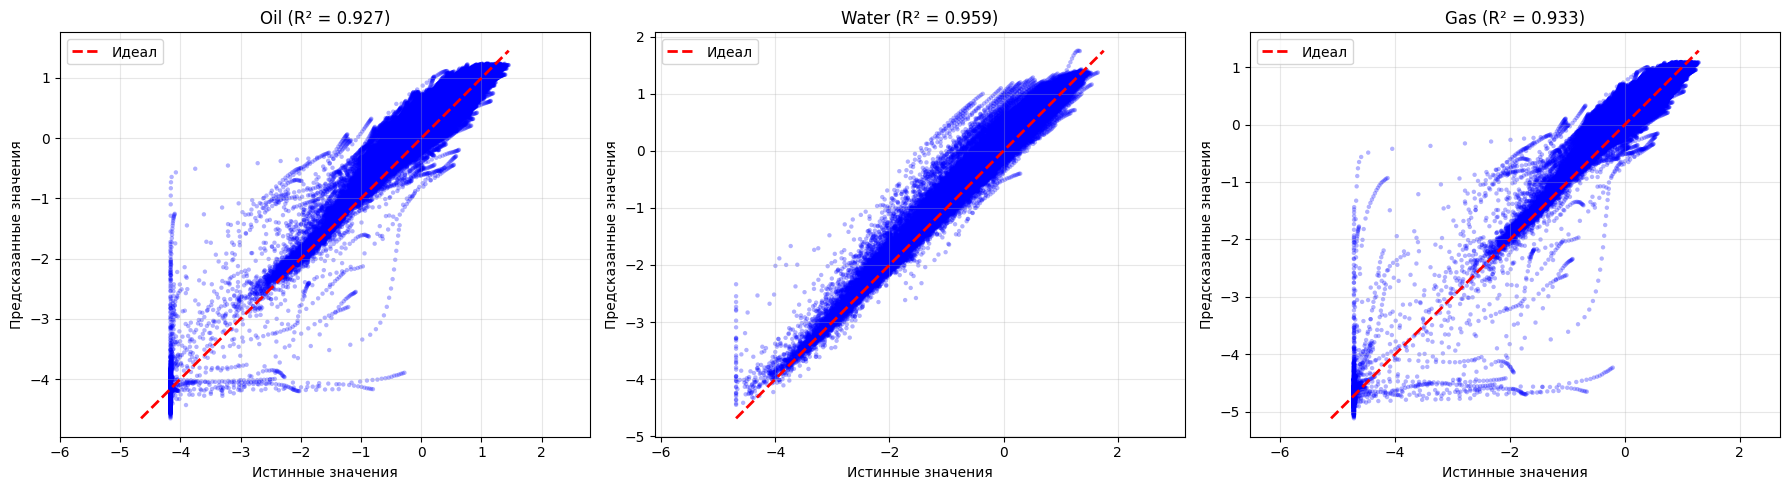

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, phase in enumerate(phases):
    ax = axes[i]
    true = phase_data[phase]['true']
    pred = phase_data[phase]['pred']
    
    ax.scatter(true, pred, alpha=0.3, s=10, c='blue', edgecolors='none')
    
    # Линия идеального соответствия
    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеал')
    
    ax.set_xlabel('Истинные значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{phase} (R² = {r2_scores[phase]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')  # одинаковый масштаб осей

plt.tight_layout()
plt.show()

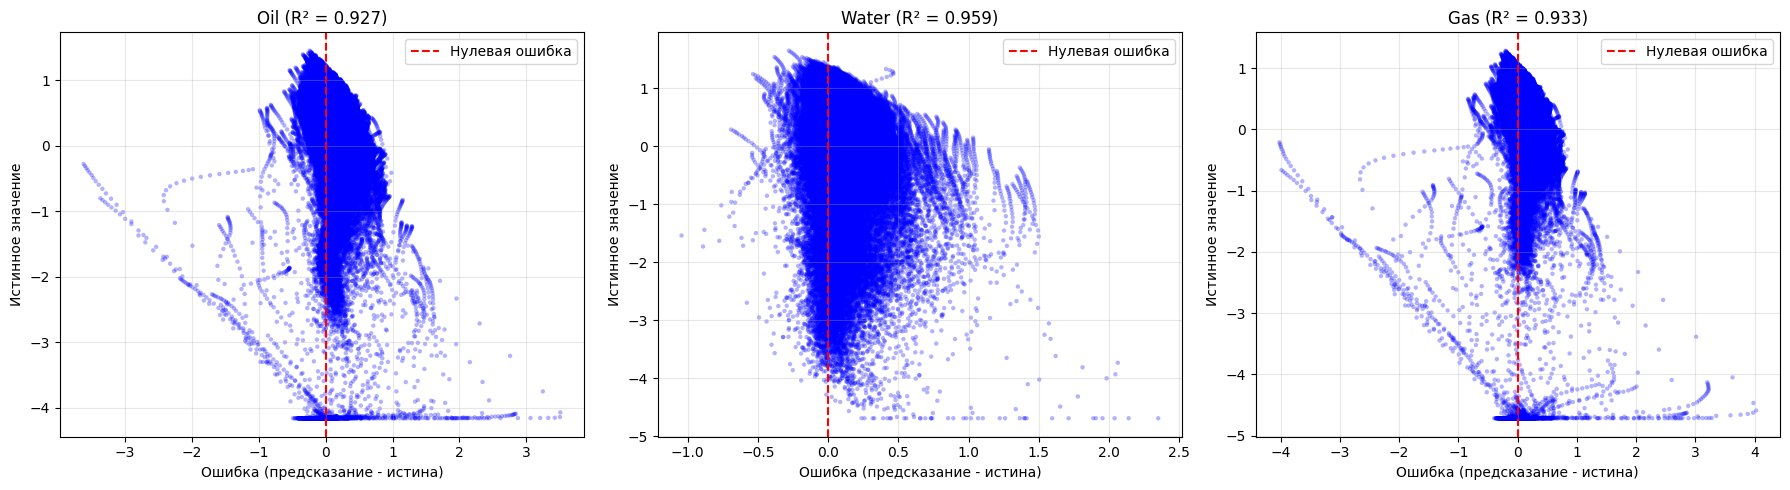

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагаем, что у нас уже есть словарь phase_data с ключами 'pred' и 'true' для каждой фазы
# (полученный из предыдущего ноутбука). Если нет, повторите шаги загрузки модели и сбора предсказаний.

# Для каждой фазы вычислим ошибку
errors = {}
for phase in phases:
    errors[phase] = phase_data[phase]['pred'] - phase_data[phase]['true']

# Построим scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, phase in enumerate(phases):
    ax = axes[i]
    true = phase_data[phase]['true']
    err = errors[phase]
    
    ax.scatter(err, true, alpha=0.3, s=10, c='blue', edgecolors='none')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Нулевая ошибка')
    ax.set_xlabel('Ошибка (предсказание - истина)')
    ax.set_ylabel('Истинное значение')
    ax.set_title(f'{phase} (R² = {r2_scores[phase]:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

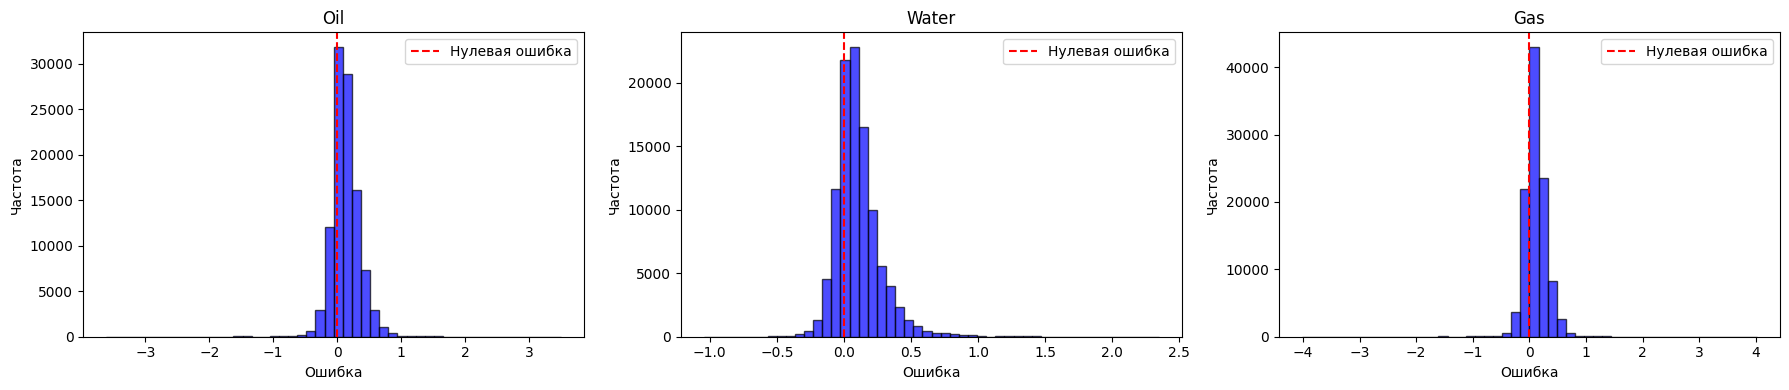

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, phase in enumerate(phases):
    ax = axes[i]
    ax.hist(errors[phase], bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', label='Нулевая ошибка')
    ax.set_xlabel('Ошибка')
    ax.set_ylabel('Частота')
    ax.set_title(f'{phase}')
    ax.legend()
plt.tight_layout()
plt.show()

In [20]:
import os
import glob
import torch
from collections import Counter

# Укажите путь к папке с обработанными графами
samples_dir = os.path.join('processed', 'samples')  # или полный путь

# Получаем список всех .pt файлов
file_paths = glob.glob(os.path.join(samples_dir, "*.pt"))

lengths = []
for i, path in enumerate(file_paths):
    try:
        data = torch.load(path, weights_only=False)
        if 'well' in data.node_types and hasattr(data['well'], 'y'):
            y_len = data['well'].y.size(2)  # размер по времени
            lengths.append(y_len)
            if y_len != 25:
                print(f"Файл {i}: {os.path.basename(path)} имеет длину {y_len}")
        else:
            print(f"Файл {i}: {os.path.basename(path)} не содержит well.y")
    except Exception as e:
        print(f"Ошибка при загрузке {path}: {e}")

# Подсчёт статистики
counter = Counter(lengths)
print("\nРаспределение длин временных рядов:")
for length, count in sorted(counter.items()):
    print(f"Длина {length}: {count} графов")

Файл 0: e1_v00001.pt имеет длину 24
Файл 1: e1_v00002.pt имеет длину 24
Файл 2: e1_v00003.pt имеет длину 24
Файл 3: e1_v00004.pt имеет длину 24
Файл 4: e1_v00005.pt имеет длину 24
Файл 5: e1_v00006.pt имеет длину 24
Файл 6: e1_v00007.pt имеет длину 24
Файл 7: e1_v00008.pt имеет длину 24
Файл 8: e1_v00009.pt имеет длину 24
Файл 9: e1_v00010.pt имеет длину 24
Файл 10: e1_v00011.pt имеет длину 24
Файл 11: e1_v00012.pt имеет длину 24
Файл 12: e1_v00013.pt имеет длину 24
Файл 13: e1_v00014.pt имеет длину 24
Файл 14: e1_v00015.pt имеет длину 24
Файл 15: e1_v00016.pt имеет длину 24
Файл 16: e1_v00017.pt имеет длину 24
Файл 17: e1_v00018.pt имеет длину 24
Файл 18: e1_v00019.pt имеет длину 24
Файл 19: e1_v00020.pt имеет длину 24
Файл 20: e1_v00021.pt имеет длину 24
Файл 21: e1_v00022.pt имеет длину 24
Файл 22: e1_v00023.pt имеет длину 24
Файл 23: e1_v00024.pt имеет длину 24
Файл 24: e1_v00025.pt имеет длину 24
Файл 25: e1_v00026.pt имеет длину 24
Файл 26: e1_v00027.pt имеет длину 24
Файл 27: e1

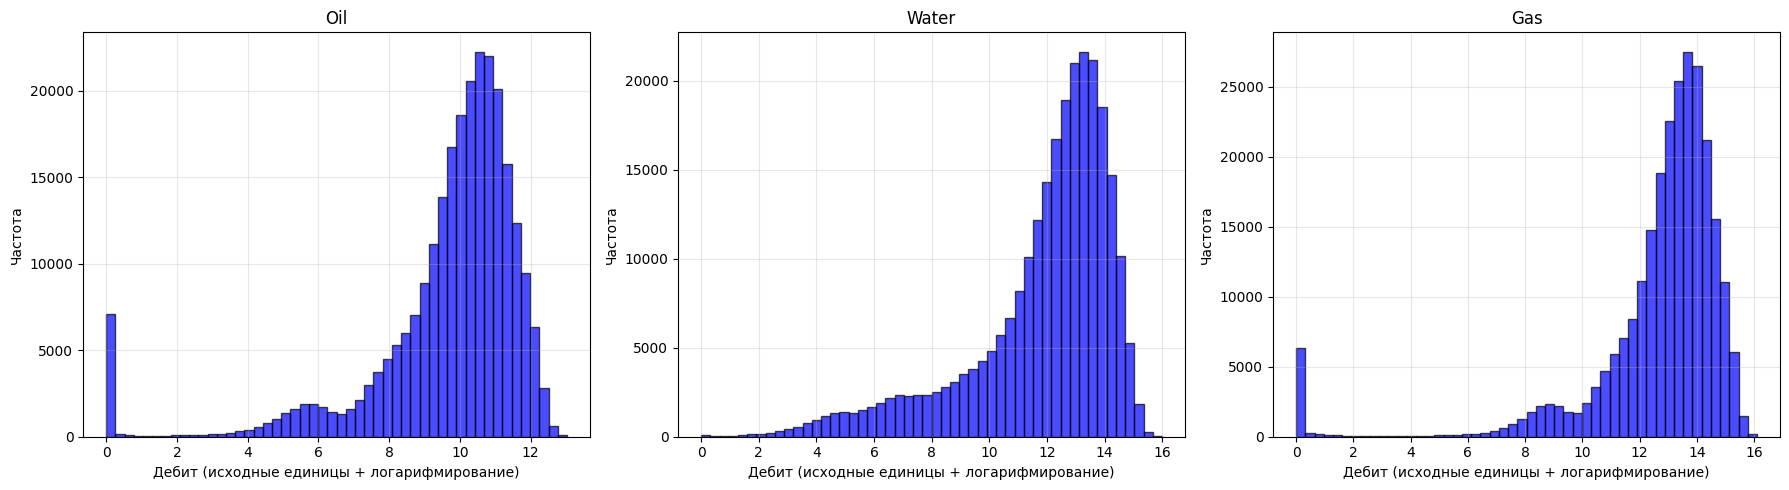

Статистики исходных значений:

Oil:
  Минимум: 0.00
  Максимум: 13.03
  Среднее: 9.62
  Ст. отклонение: 2.32
  1-й процентиль: 0.00
  99-й процентиль: 12.31

Water:
  Минимум: 0.00
  Максимум: 15.99
  Среднее: 11.82
  Ст. отклонение: 2.53
  1-й процентиль: 3.71
  99-й процентиль: 14.99

Gas:
  Минимум: 0.00
  Максимум: 16.10
  Среднее: 12.61
  Ст. отклонение: 2.68
  1-й процентиль: 0.00
  99-й процентиль: 15.38


In [21]:
import os
import glob

# Путь к папке с обработанными графами
samples_dir = os.path.join('processed', 'samples')
file_paths = glob.glob(os.path.join(samples_dir, '*.pt'))

# Списки для сбора данных по каждой фазе
oil_vals = []
water_vals = []
gas_vals = []

for path in file_paths:
    data = torch.load(path, weights_only=False)
    if 'well' in data.node_types and hasattr(data['well'], 'y'):
        y = data['well'].y  # (n_wells, 3, 25)
        # Преобразуем в numpy и собираем по фазам
        y_np = y.numpy()
        oil_vals.extend(y_np[:, 0, :].ravel())
        water_vals.extend(y_np[:, 1, :].ravel())
        gas_vals.extend(y_np[:, 2, :].ravel())

# Преобразуем в массивы numpy
oil_vals = np.array(oil_vals)
water_vals = np.array(water_vals)
gas_vals = np.array(gas_vals)

# Построим гистограммы
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phases = [('Oil', oil_vals), ('Water', water_vals), ('Gas', gas_vals)]

for i, (name, vals) in enumerate(phases):
    ax = axes[i]
    ax.hist(vals, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.set_xlabel('Дебит (исходные единицы + логарифмирование)')
    ax.set_ylabel('Частота')
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выведем ключевые статистики
print("Статистики исходных значений:")
for name, vals in phases:
    print(f"\n{name}:")
    print(f"  Минимум: {vals.min():.2f}")
    print(f"  Максимум: {vals.max():.2f}")
    print(f"  Среднее: {vals.mean():.2f}")
    print(f"  Ст. отклонение: {vals.std():.2f}")
    print(f"  1-й процентиль: {np.percentile(vals, 1):.2f}")
    print(f"  99-й процентиль: {np.percentile(vals, 99):.2f}")

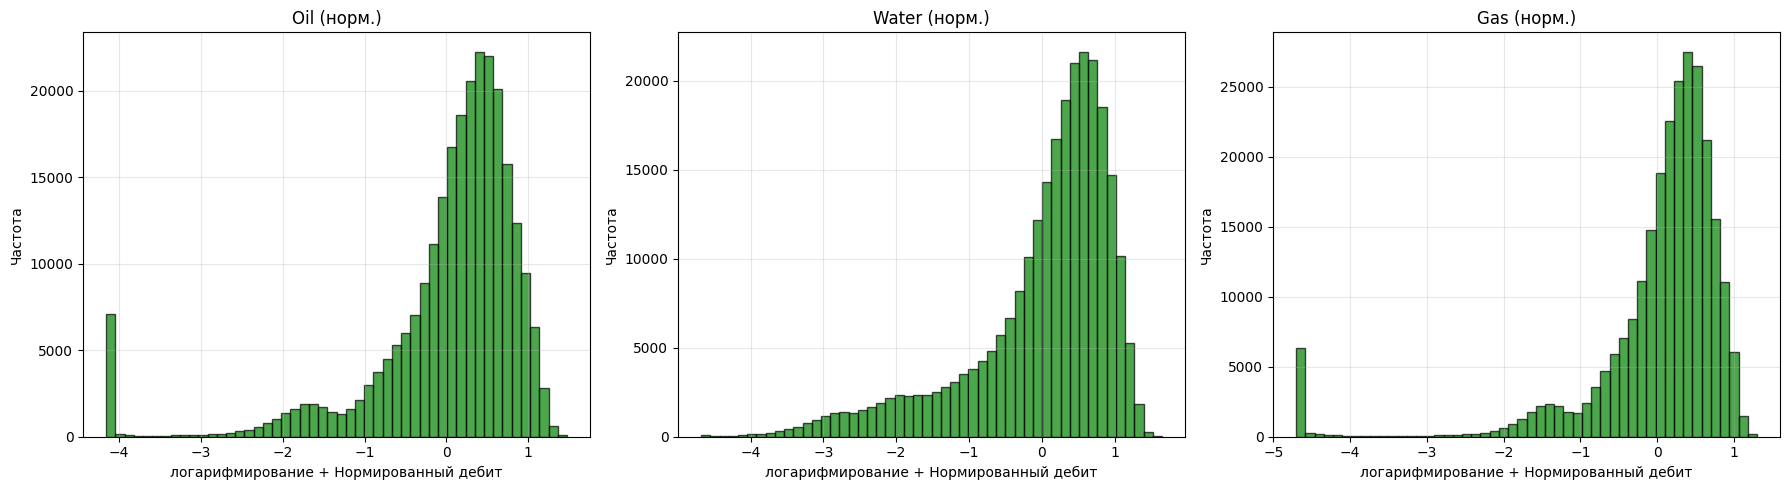

Статистики нормированных значений:

Oil (норм.):
  Минимум: -4.15
  Максимум: 1.47
  Среднее: -0.00
  Ст. отклонение: 1.00
  1-й процентиль: -4.15
  99-й процентиль: 1.16

Water (норм.):
  Минимум: -4.68
  Максимум: 1.65
  Среднее: -0.00
  Ст. отклонение: 1.00
  1-й процентиль: -3.21
  99-й процентиль: 1.25

Gas (норм.):
  Минимум: -4.70
  Максимум: 1.30
  Среднее: 0.00
  Ст. отклонение: 1.00
  1-й процентиль: -4.70
  99-й процентиль: 1.03


In [22]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt

# Путь к папке с обработанными графами
samples_dir = os.path.join('processed', 'samples')
file_paths = glob.glob(os.path.join(samples_dir, '*.pt'))

# Списки для сбора исходных данных по каждой фазе
oil_raw = []
water_raw = []
gas_raw = []

for path in file_paths:
    data = torch.load(path, weights_only=False)
    if 'well' in data.node_types and hasattr(data['well'], 'y'):
        y = data['well'].y  # (n_wells, 3, 25)
        y_np = y.numpy()
        oil_raw.extend(y_np[:, 0, :].ravel())
        water_raw.extend(y_np[:, 1, :].ravel())
        gas_raw.extend(y_np[:, 2, :].ravel())

# Преобразуем в массивы numpy
oil_raw = np.array(oil_raw)
water_raw = np.array(water_raw)
gas_raw = np.array(gas_raw)

# Вычисляем статистики для нормализации (по всей выборке)
oil_mean, oil_std = oil_raw.mean(), oil_raw.std()
water_mean, water_std = water_raw.mean(), water_raw.std()
gas_mean, gas_std = gas_raw.mean(), gas_raw.std()

# Нормируем данные
oil_norm = (oil_raw - oil_mean) / (oil_std + 1e-8)
water_norm = (water_raw - water_mean) / (water_std + 1e-8)
gas_norm = (gas_raw - gas_mean) / (gas_std + 1e-8)

# Построим гистограммы нормированных значений
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phases_norm = [('Oil (норм.)', oil_norm), ('Water (норм.)', water_norm), ('Gas (норм.)', gas_norm)]

for i, (name, vals) in enumerate(phases_norm):
    ax = axes[i]
    ax.hist(vals, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('логарифмирование + Нормированный дебит')
    ax.set_ylabel('Частота')
    ax.set_title(f'{name}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выведем ключевые статистики нормированных значений
print("Статистики нормированных значений:")
for name, vals in phases_norm:
    print(f"\n{name}:")
    print(f"  Минимум: {vals.min():.2f}")
    print(f"  Максимум: {vals.max():.2f}")
    print(f"  Среднее: {vals.mean():.2f}")
    print(f"  Ст. отклонение: {vals.std():.2f}")
    print(f"  1-й процентиль: {np.percentile(vals, 1):.2f}")
    print(f"  99-й процентиль: {np.percentile(vals, 99):.2f}")

In [23]:
print("Доля нулей в нефти:", (oil_raw == 0).mean())
print("Доля нулей в воде:", (water_raw == 0).mean())
print("Доля нулей в газе:", (gas_raw == 0).mean())

Доля нулей в нефти: 0.01308880188913746
Доля нулей в воде: 0.00035732040765597815
Доля нулей в газе: 0.01308880188913746


In [24]:
import glob

samples_dir = os.path.join('processed', 'samples')
file_paths = glob.glob(os.path.join(samples_dir, '*.pt'))

# Инициализируем счётчики: [фаза][шаг] = количество нулей / всего значений
num_steps = 24
phases = ['oil', 'water', 'gas']
zeros_count = {phase: np.zeros(num_steps, dtype=int) for phase in phases}
total_count = {phase: np.zeros(num_steps, dtype=int) for phase in phases}

for path in file_paths:
    data = torch.load(path, weights_only=False)
    if 'well' in data.node_types and hasattr(data['well'], 'y'):
        y = data['well'].y  # (n_wells, 3, 25)
        # Перебираем все скважины и шаги
        for phase_idx, phase in enumerate(phases):
            phase_data = y[:, phase_idx, :]  # (n_wells, 25)
            zeros_count[phase] += (phase_data == 0).sum(dim=0).numpy()
            total_count[phase] += (phase_data.shape[0])  # добавляем количество скважин

# Вычисляем долю нулей на каждом шаге
print("Доля нулей по временным шагам:")
for phase in phases:
    zeros_ratio = zeros_count[phase] / total_count[phase]
    print(f"\n{phase.capitalize()}:")
    for step in range(num_steps):
        print(f"  Шаг {step}: {zeros_ratio[step]:.4f} ({zeros_count[phase][step]} / {total_count[phase][step]})")

Доля нулей по временным шагам:

Oil:
  Шаг 0: 0.0194 (208 / 10728)
  Шаг 1: 0.0160 (172 / 10728)
  Шаг 2: 0.0157 (168 / 10728)
  Шаг 3: 0.0148 (159 / 10728)
  Шаг 4: 0.0146 (157 / 10728)
  Шаг 5: 0.0139 (149 / 10728)
  Шаг 6: 0.0137 (147 / 10728)
  Шаг 7: 0.0135 (145 / 10728)
  Шаг 8: 0.0134 (144 / 10728)
  Шаг 9: 0.0130 (139 / 10728)
  Шаг 10: 0.0127 (136 / 10728)
  Шаг 11: 0.0126 (135 / 10728)
  Шаг 12: 0.0123 (132 / 10728)
  Шаг 13: 0.0122 (131 / 10728)
  Шаг 14: 0.0121 (130 / 10728)
  Шаг 15: 0.0120 (129 / 10728)
  Шаг 16: 0.0117 (126 / 10728)
  Шаг 17: 0.0116 (124 / 10728)
  Шаг 18: 0.0116 (124 / 10728)
  Шаг 19: 0.0116 (124 / 10728)
  Шаг 20: 0.0116 (124 / 10728)
  Шаг 21: 0.0116 (124 / 10728)
  Шаг 22: 0.0114 (122 / 10728)
  Шаг 23: 0.0113 (121 / 10728)

Water:
  Шаг 0: 0.0021 (22 / 10728)
  Шаг 1: 0.0013 (14 / 10728)
  Шаг 2: 0.0012 (13 / 10728)
  Шаг 3: 0.0008 (9 / 10728)
  Шаг 4: 0.0007 (8 / 10728)
  Шаг 5: 0.0005 (5 / 10728)
  Шаг 6: 0.0003 (3 / 10728)
  Шаг 7: 0.0002 (2 / 1

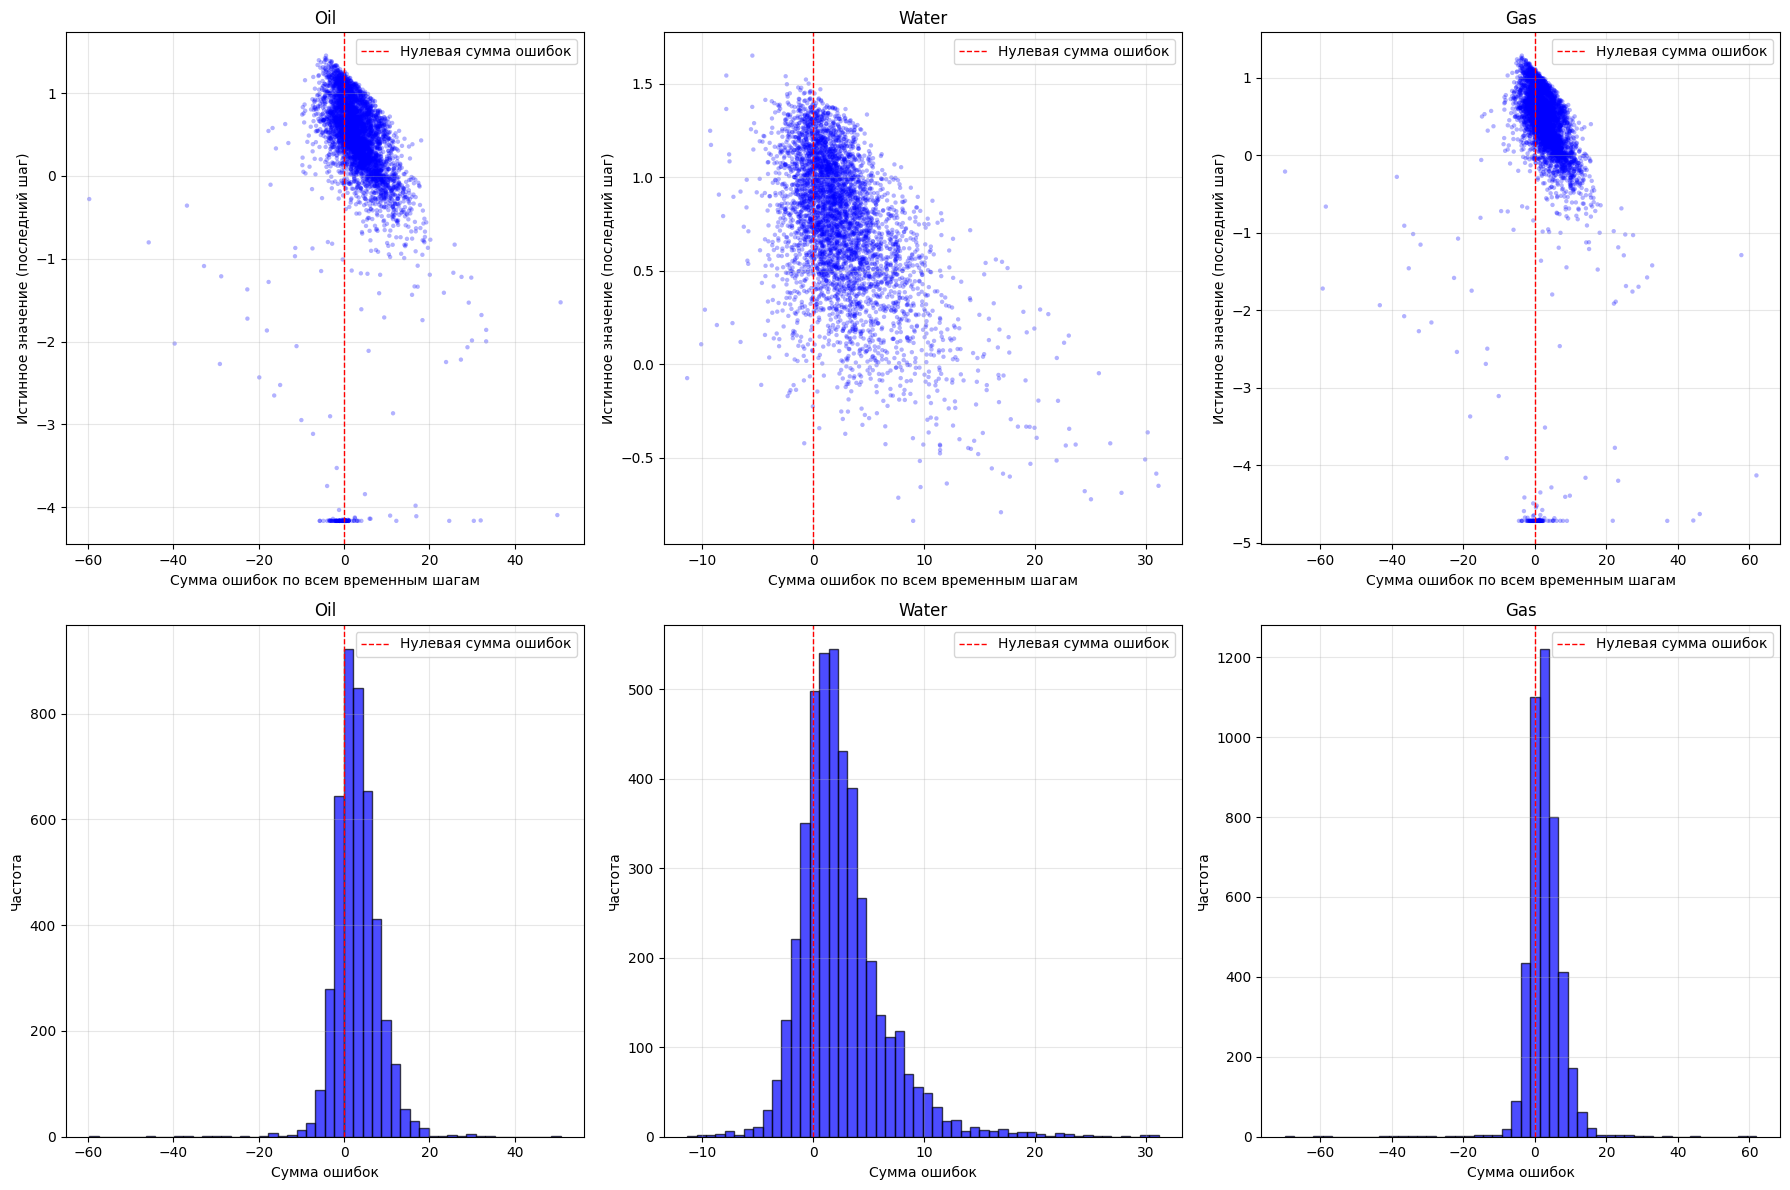

In [25]:
model.eval()

# Собираем предсказания и истины для всех валидационных графов
all_preds = []
all_targets = []

with torch.no_grad():
    for batch, _ in val_loader:
        batch = batch.to(device)
        pred = model(batch)                # (total_wells_in_batch, 3, 24)
        target = batch['well'].y           # (total_wells_in_batch, 3, 24)
        all_preds.append(pred.cpu())
        all_targets.append(target.cpu())

preds = torch.cat(all_preds, dim=0)        # (total_wells, 3, 24)
targets = torch.cat(all_targets, dim=0)    # (total_wells, 3, 24)

phases = ['Oil', 'Water', 'Gas']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, phase in enumerate(phases):
    # Для каждой фазы: берём все скважины, все временные шаги
    pred_phase = preds[:, i, :]   # (total_wells, 24)
    true_phase = targets[:, i, :] # (total_wells, 24)
    
    # Ошибка по каждому временному шагу
    errors = pred_phase - true_phase  # (total_wells, 24)
    
    # Сумма ошибок по временным шагам для каждой скважины
    sum_errors = errors.sum(dim=1).numpy()  # (total_wells,)
    
    # Истинное значение на последнем временном шаге
    last_true = true_phase[:, -1].numpy()   # (total_wells,)
    
    # --- Scatter plot: сумма ошибок vs последнее истинное значение ---
    ax_scatter = axes[0, i]
    ax_scatter.scatter(sum_errors, last_true, alpha=0.3, s=10, c='blue', edgecolors='none')
    ax_scatter.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевая сумма ошибок')
    ax_scatter.set_xlabel('Сумма ошибок по всем временным шагам')
    ax_scatter.set_ylabel('Истинное значение (последний шаг)')
    ax_scatter.set_title(f'{phase}')
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()
    
    # --- Гистограмма: распределение суммы ошибок ---
    ax_hist = axes[1, i]
    ax_hist.hist(sum_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевая сумма ошибок')
    ax_hist.set_xlabel('Сумма ошибок')
    ax_hist.set_ylabel('Частота')
    ax_hist.set_title(f'{phase}')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

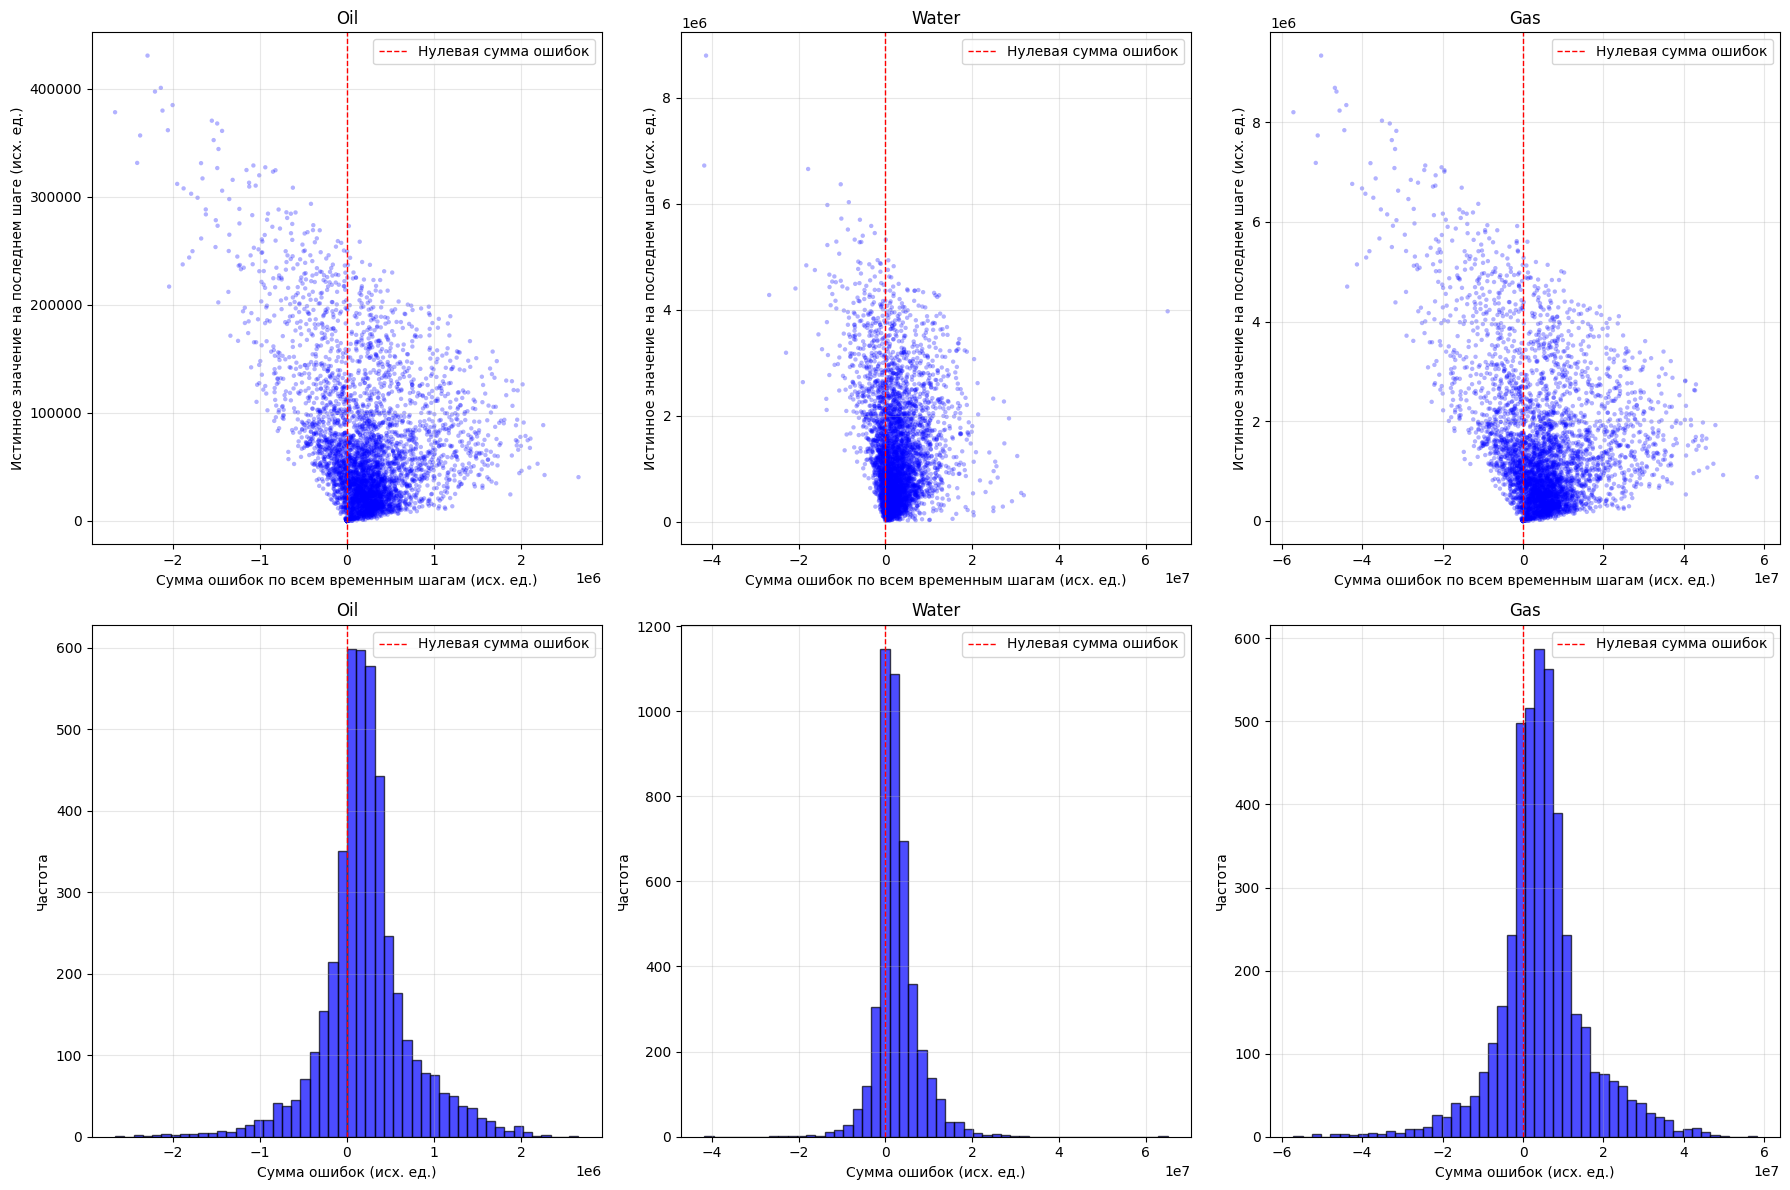

In [26]:
model.eval()

# Собираем нормализованные предсказания и истины
all_preds_norm = []
all_targets_norm = []

with torch.no_grad():
    for batch, _ in val_loader:
        batch = batch.to(device)
        pred_norm = model(batch)                # (total_wells_in_batch, 3, out_seq_len)
        target_norm = batch['well'].y
        all_preds_norm.append(pred_norm.cpu())
        all_targets_norm.append(target_norm.cpu())

preds_norm = torch.cat(all_preds_norm, dim=0)   # (total_wells, 3, out_seq_len)
targets_norm = torch.cat(all_targets_norm, dim=0)

# Получаем статистики нормализации из датасета (нужен доступ к одному из датасетов, например, val_dataset)
# val_dataset можно получить из val_loader.dataset
val_dataset = val_loader.dataset
y_mean = val_dataset.y_global_mean  # тензор (1, 3, 1)
y_std  = val_dataset.y_global_std   # тензор (1, 3, 1)

# Переводим статистики на CPU, если они на GPU
y_mean = y_mean.cpu()
y_std = y_std.cpu()

# Обратное преобразование в исходные единицы
# 1) Денормализация (обратная стандартизация)
preds_log = preds_norm * y_std + y_mean
targets_log = targets_norm * y_std + y_mean

# 2) Экспоненцирование (обратное логарифмирование)
preds_original = torch.expm1(preds_log)
targets_original = torch.expm1(targets_log)

# Теперь preds_original и targets_original имеют форму (total_wells, 3, out_seq_len) в физических единицах

phases = ['Oil', 'Water', 'Gas']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, phase in enumerate(phases):
    # Берём данные для фазы
    pred_phase = preds_original[:, i, :]   # (total_wells, out_seq_len)
    true_phase = targets_original[:, i, :] # (total_wells, out_seq_len)
    
    # Ошибка по каждому временному шагу
    errors = pred_phase - true_phase
    # Сумма ошибок по всем шагам для каждой скважины
    sum_errors = errors.sum(dim=1).numpy()
    # Истинное значение на последнем шаге
    last_true = true_phase[:, -1].numpy()
    
    # Scatter plot
    ax_scatter = axes[0, i]
    ax_scatter.scatter(sum_errors, last_true, alpha=0.3, s=10, c='blue', edgecolors='none')
    ax_scatter.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевая сумма ошибок')
    ax_scatter.set_xlabel('Сумма ошибок по всем временным шагам (исх. ед.)')
    ax_scatter.set_ylabel('Истинное значение на последнем шаге (исх. ед.)')
    ax_scatter.set_title(f'{phase}')
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.legend()
    
    # Гистограмма
    ax_hist = axes[1, i]
    ax_hist.hist(sum_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax_hist.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Нулевая сумма ошибок')
    ax_hist.set_xlabel('Сумма ошибок (исх. ед.)')
    ax_hist.set_ylabel('Частота')
    ax_hist.set_title(f'{phase}')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
print("feat_list:", feat_list)

feat_list: ['GV', 'PERMX', 'PERMY', 'PERMZ', 'PORO', 'SGAS', 'SOIL', 'SWAT', 'X', 'Y', 'Z']


In [28]:
samples_dir = 'processed/samples'
file_paths = [os.path.join(samples_dir, f) for f in os.listdir(samples_dir) if f.endswith('.pt')]
sample_path = file_paths[0]
data = torch.load(sample_path, weights_only=False)

print("Форма cell.x:", data['cell'].x.shape)
cell_x = data['cell'].x.numpy()

# Вычислим среднее, игнорируя NaN
col_means = np.nanmean(cell_x, axis=0)
col_nans = np.isnan(cell_x).sum(axis=0)

print("Средние значения по столбцам (в порядке хранения):")
for i, (mean_val, nan_count) in enumerate(zip(col_means, col_nans)):
    print(f"Столбец {i}: {mean_val:.2f} (NaN count: {nan_count})")
    # ['GV', 'PERMX', 'PERMY', 'PERMZ', 'PORO', 'SGAS', 'SOIL', 'SWAT', 'X', 'Y', 'Z']

Форма cell.x: torch.Size([6480, 11])
Средние значения по столбцам (в порядке хранения):
Столбец 0: 8770.84 (NaN count: 0)
Столбец 1: 3.49 (NaN count: 0)
Столбец 2: 3.27 (NaN count: 0)
Столбец 3: 2.70 (NaN count: 0)
Столбец 4: 0.17 (NaN count: 0)
Столбец 5: 0.00 (NaN count: 1296)
Столбец 6: 0.26 (NaN count: 1296)
Столбец 7: 0.74 (NaN count: 1296)
Столбец 8: 1200.00 (NaN count: 0)
Столбец 9: 900.00 (NaN count: 0)
Столбец 10: 2453.22 (NaN count: 0)


In [29]:
import torch
import numpy as np
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
from tqdm import tqdm

In [30]:
# ----------------------------------------------------------------------
# 1. Сбор предсказаний и ошибок
# ----------------------------------------------------------------------
model.eval()

val_dataset = val_loader.dataset
y_mean = val_dataset.y_global_mean.cpu()
y_std = val_dataset.y_global_std.cpu()

# Списки для накопления данных по всем скважинам
all_records = []   # каждый элемент: словарь с graph_name, well_idx, sum_error, cum_true

with torch.no_grad():
    for batch, sample_names in tqdm(val_loader, desc="Обработка батчей"):
        batch = batch.to(device)
        pred_norm = model(batch)
        target_norm = batch['well'].y
        pred_norm = pred_norm.cpu()
        target_norm = target_norm.cpu()

        # Денормализация и обратное логарифмирование
        pred_log = pred_norm * y_std + y_mean
        target_log = target_norm * y_std + y_mean
        pred_orig = torch.expm1(pred_log)   # (n_wells, 3, out_seq_len)
        target_orig = torch.expm1(target_log)

        # Индексы графов для каждой скважины
        well_batch = batch['well'].batch.cpu().numpy()  # (n_wells,)

        n_wells = pred_orig.size(0)
        for w in range(n_wells):
            graph_idx = well_batch[w]
            graph_name = sample_names[graph_idx]
            # Истина и предсказание для этой скважины
            true = target_orig[w].numpy()   # (3, out_seq_len)
            pred = pred_orig[w].numpy()
            error = pred - true
            sum_error = error.sum(axis=1)   # (3,)
            cum_true = true.sum(axis=1)     # накопленная добыча по фазам

            all_records.append({
                'graph_name': graph_name,
                'well_index_in_graph': w,
                'graph_idx': graph_idx,
                'sum_error_oil': sum_error[0],
                'sum_error_water': sum_error[1],
                'sum_error_gas': sum_error[2],
                'cum_oil': cum_true[0],
                'cum_water': cum_true[1],
                'cum_gas': cum_true[2]
            })

# Преобразуем в DataFrame
df_all = pd.DataFrame(all_records)

Обработка батчей: 100%|██████████| 313/313 [00:21<00:00, 14.37it/s]


In [31]:
# ----------------------------------------------------------------------
# 2. Определение процентилей и меток выбросов
# ----------------------------------------------------------------------
phases = ['Oil', 'Water', 'Gas']
percentiles = {}
for i, phase in enumerate(phases):
    col = f'sum_error_{phase.lower()}'
    values = df_all[col].values
    p10 = np.percentile(values, 10)
    p90 = np.percentile(values, 90)
    percentiles[phase] = (p10, p90)
    print(f"{phase}: 10% = {p10:.3f}, 90% = {p90:.3f}")

# Добавляем флаги выбросов для каждой фазы
for i, phase in enumerate(phases):
    col = f'sum_error_{phase.lower()}'
    p10, p90 = percentiles[phase]
    df_all[f'outlier_{phase.lower()}'] = (df_all[col] <= p10) | (df_all[col] >= p90)

# Скважина считается выбросной, если она выброс хотя бы по одной фазе
df_all['outlier_any'] = df_all[[f'outlier_{p.lower()}' for p in phases]].any(axis=1)

# Фильтруем выбросы
df_outliers = df_all[df_all['outlier_any']].copy()
print(f"Всего скважин: {len(df_all)}, из них выбросов: {len(df_outliers)}")

Oil: 10% = -292856.844, 90% = 815624.438
Water: 10% = -1724667.375, 90% = 8397556.000
Gas: 10% = -6232658.000, 90% = 17659072.000
Всего скважин: 4383, из них выбросов: 1531


In [32]:
# ----------------------------------------------------------------------
# 3. Извлечение характеристик ячеек для выбросных скважин
# ----------------------------------------------------------------------
# Путь к папке с графами
samples_dir = 'processed/samples'

# Индексы признаков в data['cell'].x (по результатам проверки)
idx_poro = 4
idx_permx = 1
# Для PERMY и PERMZ (если понадобятся)
idx_permy = 2
idx_permz = 3

# Кэш для загруженных графов
graph_cache = {}

outliers_details = []

for idx, row in tqdm(df_outliers.iterrows(), total=len(df_outliers), desc="Загрузка графов"):
    graph_name = row['graph_name']
    if not graph_name.endswith('.pt'):
        graph_name += '.pt'
    graph_path = os.path.join(samples_dir, graph_name)

    if graph_path not in graph_cache:
        graph_cache[graph_path] = torch.load(graph_path, weights_only=False)
    data = graph_cache[graph_path]

    well_idx = row['well_index_in_graph']

    # Рёбра cell -> well
    edge_index = data['cell', 'linked_to', 'well'].edge_index  # (2, E)
    mask = edge_index[1] == well_idx
    cell_indices = edge_index[0][mask].numpy()

    # Признаки ячеек
    cell_x = data['cell'].x.numpy()  # (N_cells, 11)
    selected_cells = cell_x[cell_indices]

    # Метки коллектора (NTG) – хранятся в data['cell'].labels
    if hasattr(data['cell'], 'labels'):
        labels = data['cell'].labels.numpy().flatten()
        selected_labels = labels[cell_indices]
        mean_label = 1 - selected_labels.mean()   # среднее значение меток (0/1)
    else:
        mean_label = np.nan

    # Средние значения признаков
    mean_poro = np.nanmean(selected_cells[:, idx_poro]) if len(selected_cells) else np.nan
    mean_permx = np.nanmean(selected_cells[:, idx_permx]) if len(selected_cells) else np.nan
    # Среднее всех 11 признаков (игнорируя NaN)
    mean_all_features = np.nanmean(selected_cells) if len(selected_cells) else np.nan

    # Собираем результат
    outliers_details.append({
        'graph_name': graph_name,
        'well_index': well_idx,
        'cum_oil': row['cum_oil'],
        'cum_water': row['cum_water'],
        'cum_gas': row['cum_gas'],
        'mean_poro': mean_poro,
        'mean_permx': mean_permx,
        'mean_label': mean_label,
        'mean_all_features': mean_all_features,
        'sum_error_oil': row['sum_error_oil'],
        'sum_error_water': row['sum_error_water'],
        'sum_error_gas': row['sum_error_gas'],
        'outlier_oil': row['outlier_oil'],
        'outlier_water': row['outlier_water'],
        'outlier_gas': row['outlier_gas'],
    })

# Создаём DataFrame
df_outliers_table = pd.DataFrame(outliers_details)

# Добавляем тип выброса (какие фазы)
def outlier_type_str(row):
    types = []
    if row['outlier_oil']: types.append('Oil')
    if row['outlier_water']: types.append('Water')
    if row['outlier_gas']: types.append('Gas')
    return ', '.join(types) if types else 'None'
df_outliers_table['outlier_type'] = df_outliers_table.apply(outlier_type_str, axis=1)

# Сохраняем таблицу
df_outliers_table.to_csv('outliers_analysis.csv', index=False)
print("Таблица сохранена в outliers_analysis.csv")

Загрузка графов:   0%|          | 0/1531 [00:00<?, ?it/s]c:\Users\Damir\Desktop\GNN_dataset_test\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
Загрузка графов: 100%|██████████| 1531/1531 [00:03<00:00, 414.05it/s]

Таблица сохранена в outliers_analysis.csv


<Figure size 1000x600 with 0 Axes>

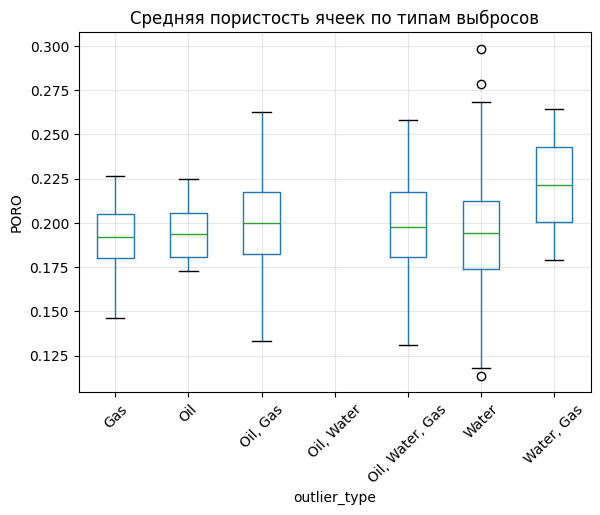

<Figure size 1000x600 with 0 Axes>

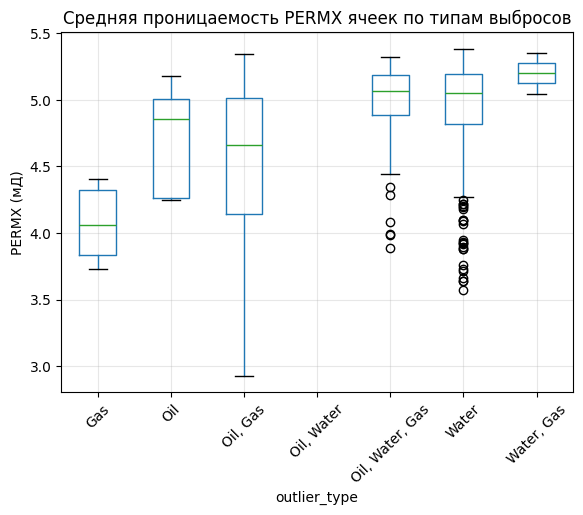

<Figure size 1000x600 with 0 Axes>

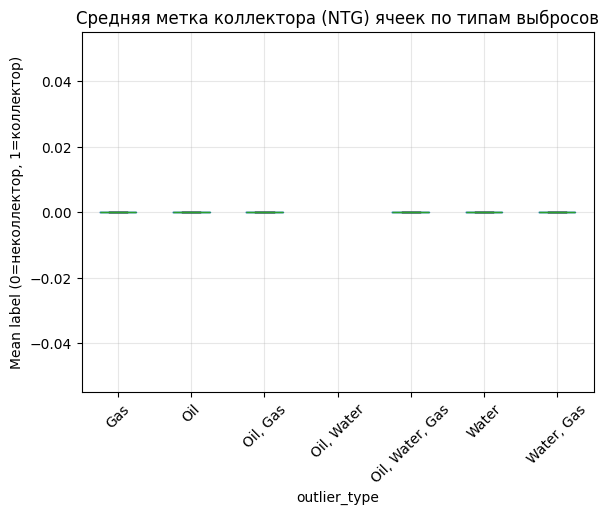

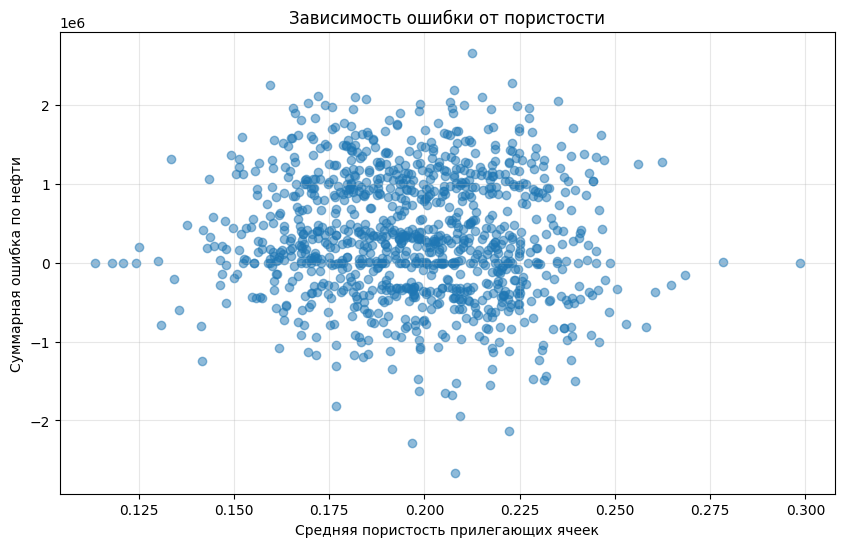

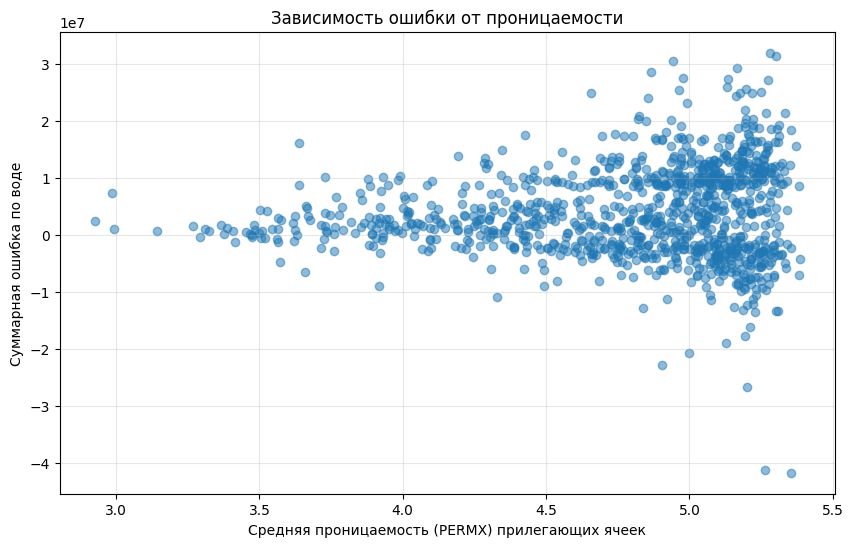

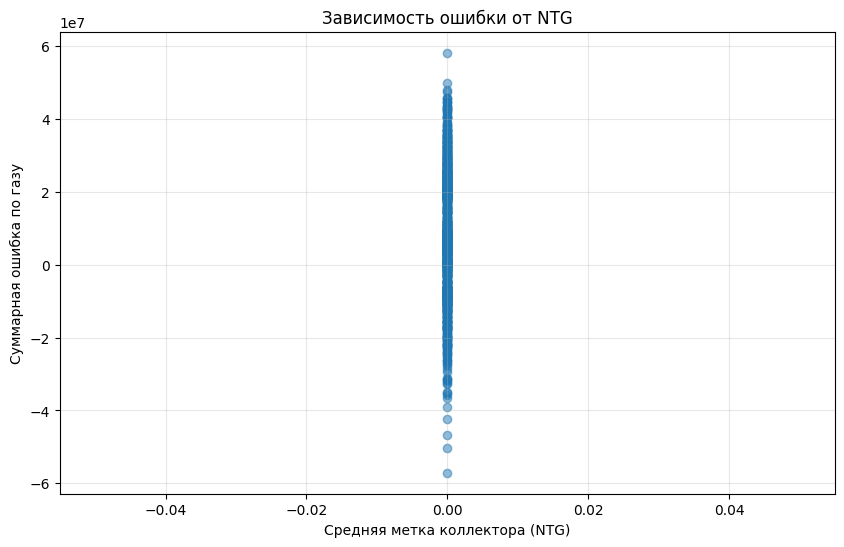

In [33]:
# ----------------------------------------------------------------------
# 4. Построение графиков
# ----------------------------------------------------------------------
# Boxplot среднего PORO по типам выбросов
plt.figure(figsize=(10,6))
df_outliers_table.boxplot(column='mean_poro', by='outlier_type')
plt.title('Средняя пористость ячеек по типам выбросов')
plt.suptitle('')
plt.xticks(rotation=45)
plt.ylabel('PORO')
plt.grid(alpha=0.3)
plt.show()

# Boxplot средней проницаемости (PERMX)
plt.figure(figsize=(10,6))
df_outliers_table.boxplot(column='mean_permx', by='outlier_type')
plt.title('Средняя проницаемость PERMX ячеек по типам выбросов')
plt.suptitle('')
plt.xticks(rotation=45)
plt.ylabel('PERMX (мД)')
plt.grid(alpha=0.3)
plt.show()

# Boxplot средней метки (NTG) – коллекторность
plt.figure(figsize=(10,6))
df_outliers_table.boxplot(column='mean_label', by='outlier_type')
plt.title('Средняя метка коллектора (NTG) ячеек по типам выбросов')
plt.suptitle('')
plt.xticks(rotation=45)
plt.ylabel('Mean label (0=неколлектор, 1=коллектор)')
plt.grid(alpha=0.3)
plt.show()

# Scatter plot: зависимость суммарной ошибки по нефти от средней пористости
plt.figure(figsize=(10,6))
plt.scatter(df_outliers_table['mean_poro'], df_outliers_table['sum_error_oil'], alpha=0.5)
plt.xlabel('Средняя пористость прилегающих ячеек')
plt.ylabel('Суммарная ошибка по нефти')
plt.title('Зависимость ошибки от пористости')
plt.grid(alpha=0.3)
plt.show()

# Scatter plot: ошибка по воде от средней проницаемости
plt.figure(figsize=(10,6))
plt.scatter(df_outliers_table['mean_permx'], df_outliers_table['sum_error_water'], alpha=0.5)
plt.xlabel('Средняя проницаемость (PERMX) прилегающих ячеек')
plt.ylabel('Суммарная ошибка по воде')
plt.title('Зависимость ошибки от проницаемости')
plt.grid(alpha=0.3)
plt.show()

# Scatter plot: ошибка по газу от средней метки коллектора
plt.figure(figsize=(10,6))
plt.scatter(df_outliers_table['mean_label'], df_outliers_table['sum_error_gas'], alpha=0.5)
plt.xlabel('Средняя метка коллектора (NTG)')
plt.ylabel('Суммарная ошибка по газу')
plt.title('Зависимость ошибки от NTG')
plt.grid(alpha=0.3)
plt.show()

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Стиль графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Список признаков для анализа
features = ['mean_poro', 'mean_permx', 'mean_label', 'mean_all_features']
phases = ['Oil', 'Water', 'Gas']
error_cols = ['sum_error_oil', 'sum_error_water', 'sum_error_gas']


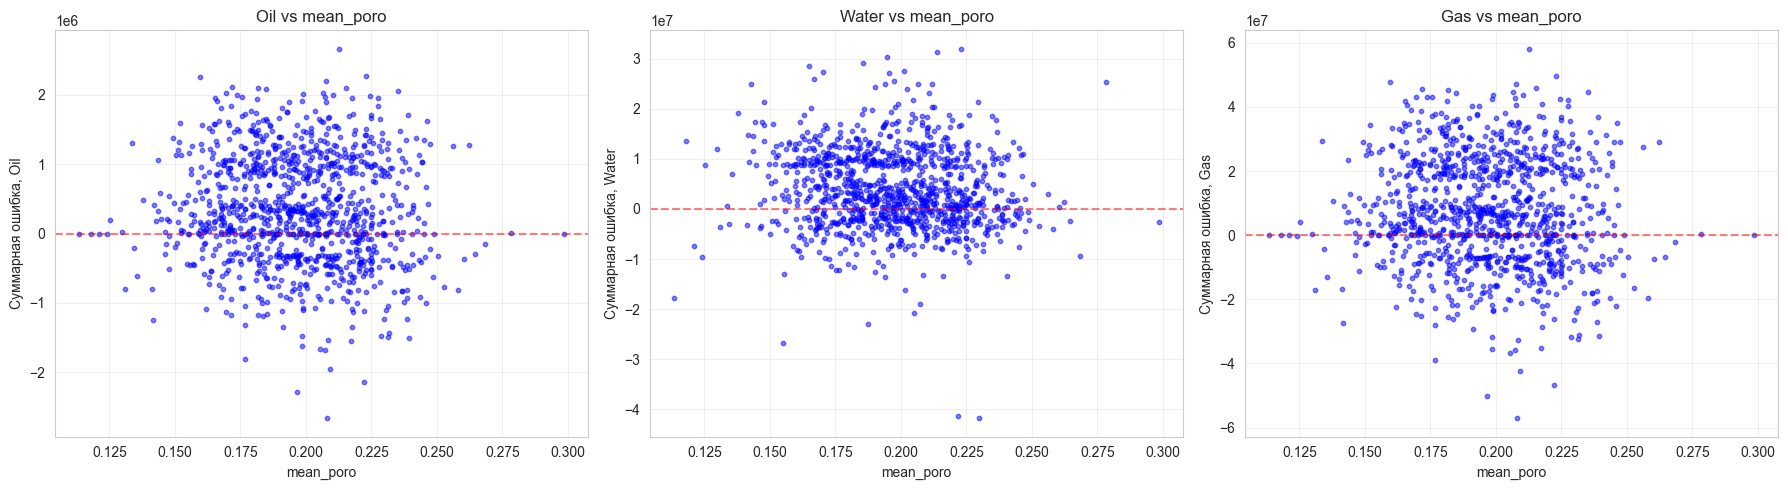

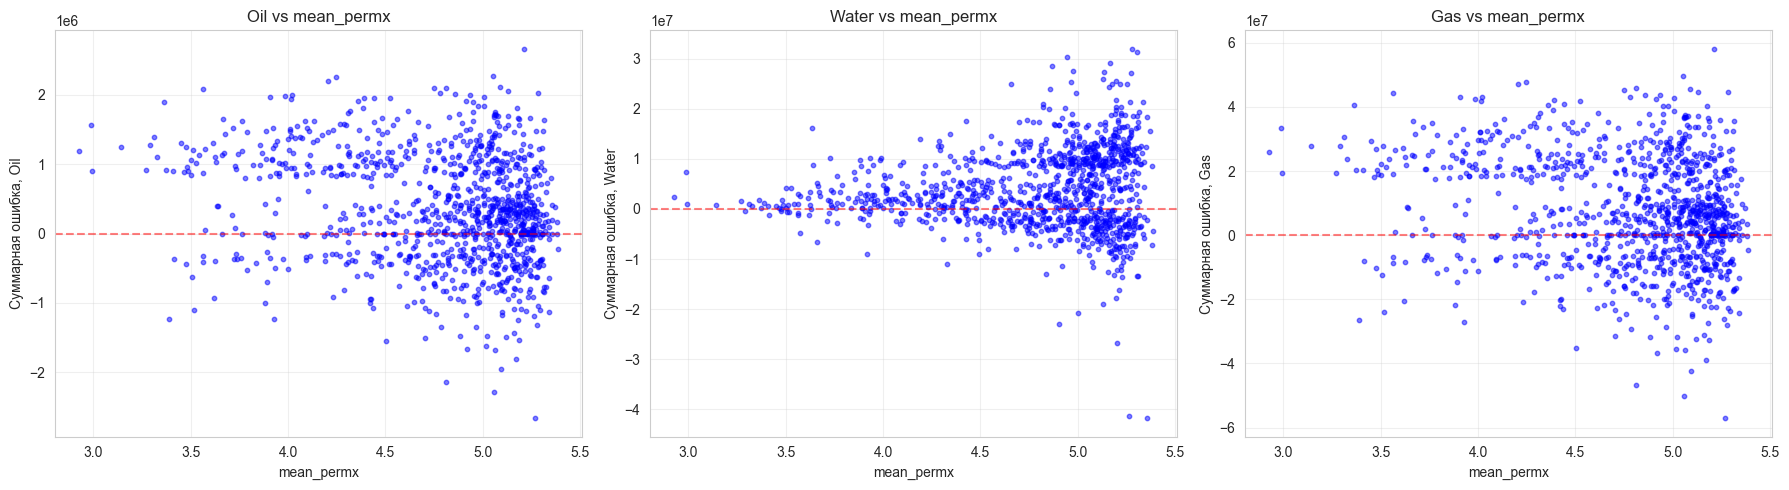

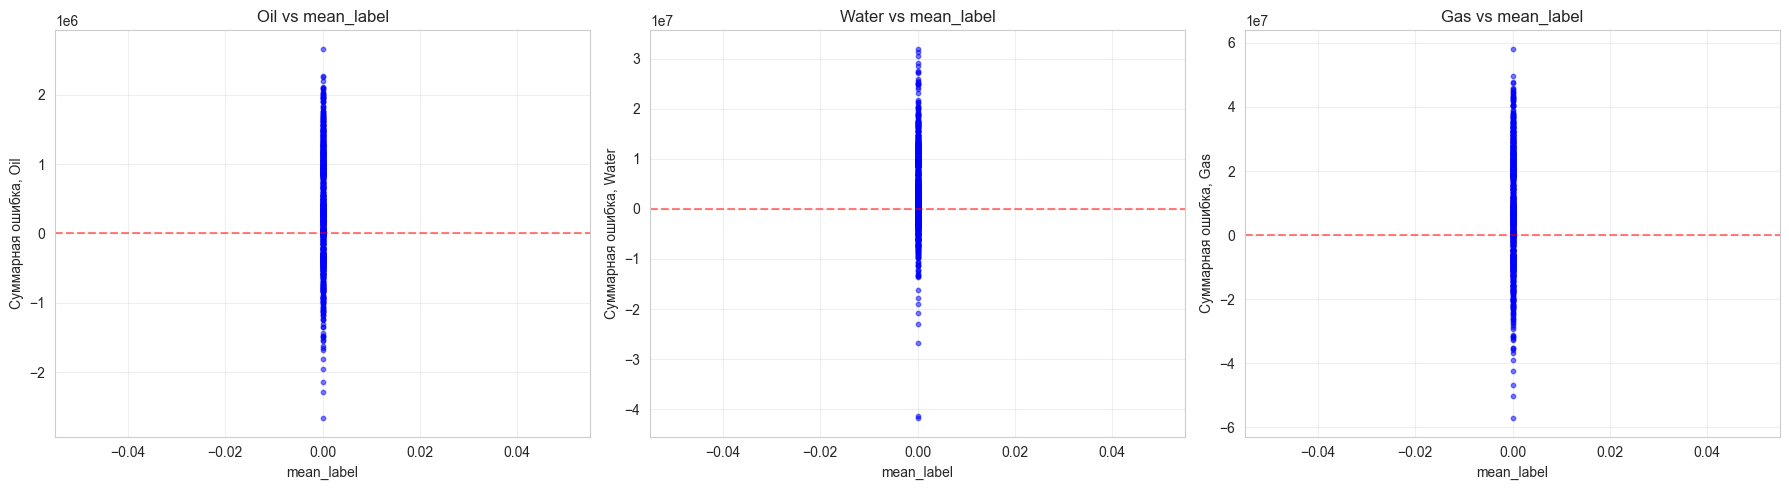

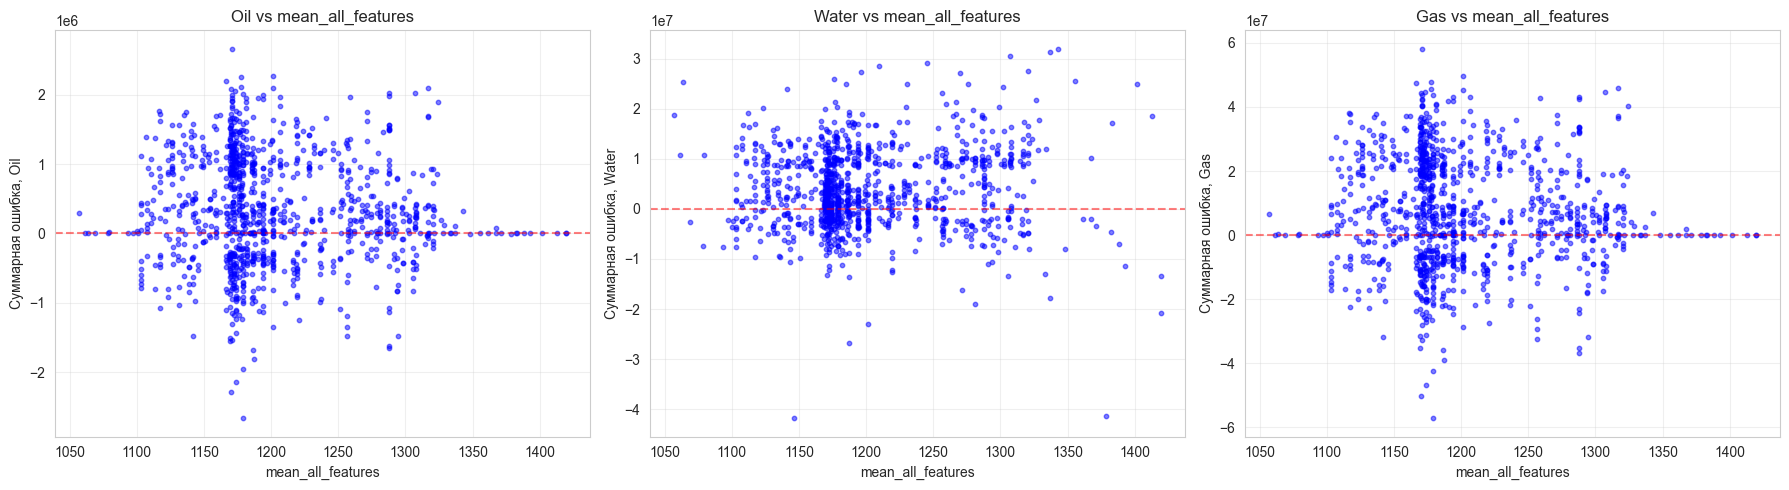

In [35]:
# ----------------------------------------------------------------------
# 1. Scatter plots: ошибка vs признак для каждой фазы
# ----------------------------------------------------------------------
for feature in features:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, phase in enumerate(phases):
        ax = axes[i]
        x = df_outliers_table[feature]
        y = df_outliers_table[error_cols[i]]
        ax.scatter(x, y, alpha=0.5, s=10, c='blue')
        ax.set_xlabel(feature)
        ax.set_ylabel(f'Суммарная ошибка, {phase}')
        ax.set_title(f'{phase} vs {feature}')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
# ----------------------------------------------------------------------
# 1. Подсчёт количества выбросных скважин по типам фаз
# ----------------------------------------------------------------------
outlier_counts = df_outliers_table['outlier_type'].value_counts().sort_index()
print("\nКоличество выбросных скважин по типам фаз:")
print(outlier_counts.to_string())

# Можно также вывести проценты от общего числа выбросов
total_outliers = len(df_outliers_table)
print("\nПроцент от всех выбросов:")
for typ, cnt in outlier_counts.items():
    print(f"  {typ}: {cnt} ({cnt/total_outliers*100:.1f}%)")


Количество выбросных скважин по типам фаз:
outlier_type
Gas                 11
Oil                 12
Oil, Gas           630
Oil, Water           1
Oil, Water, Gas    235
Water              640
Water, Gas           2

Процент от всех выбросов:
  Gas: 11 (0.7%)
  Oil: 12 (0.8%)
  Oil, Gas: 630 (41.1%)
  Oil, Water: 1 (0.1%)
  Oil, Water, Gas: 235 (15.3%)
  Water: 640 (41.8%)
  Water, Gas: 2 (0.1%)


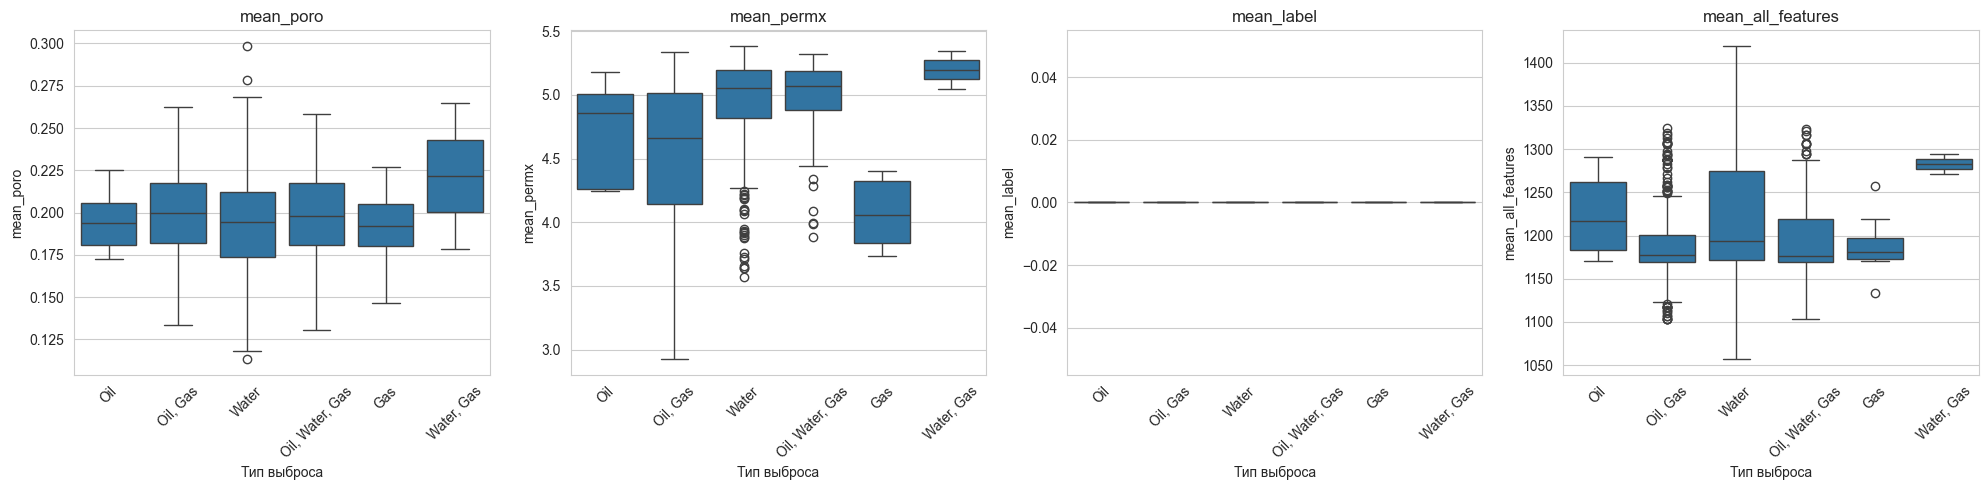

In [37]:
# ----------------------------------------------------------------------
# 2. Box plots: распределение признаков по типам выбросов (outlier_type)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feature in enumerate(features):
    ax = axes[i]
    # Убираем NaN для чистоты
    data_for_box = df_outliers_table.dropna(subset=[feature])
    sns.boxplot(x='outlier_type', y=feature, data=data_for_box, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Тип выброса')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

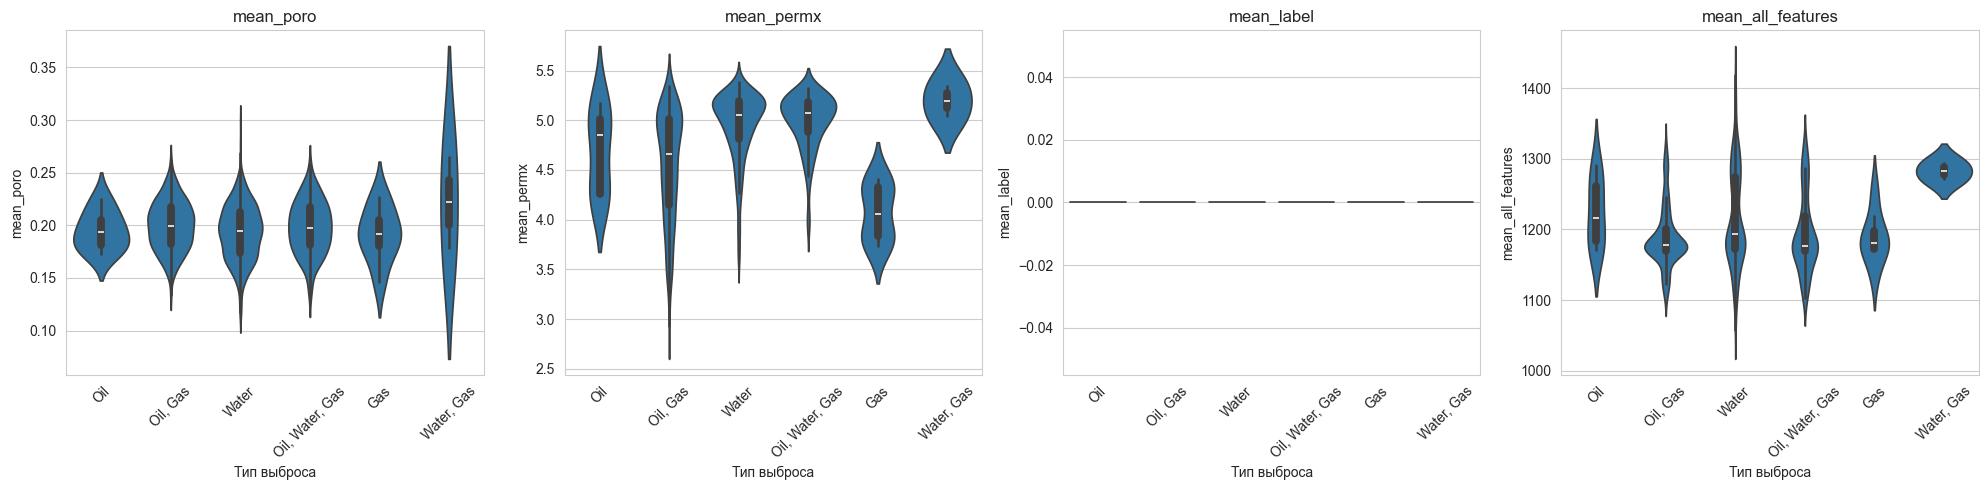

In [38]:
# ----------------------------------------------------------------------
# 3. Violin plots (более информативные, чем box plots)
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feature in enumerate(features):
    ax = axes[i]
    data_for_violin = df_outliers_table.dropna(subset=[feature])
    sns.violinplot(x='outlier_type', y=feature, data=data_for_violin, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Тип выброса')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

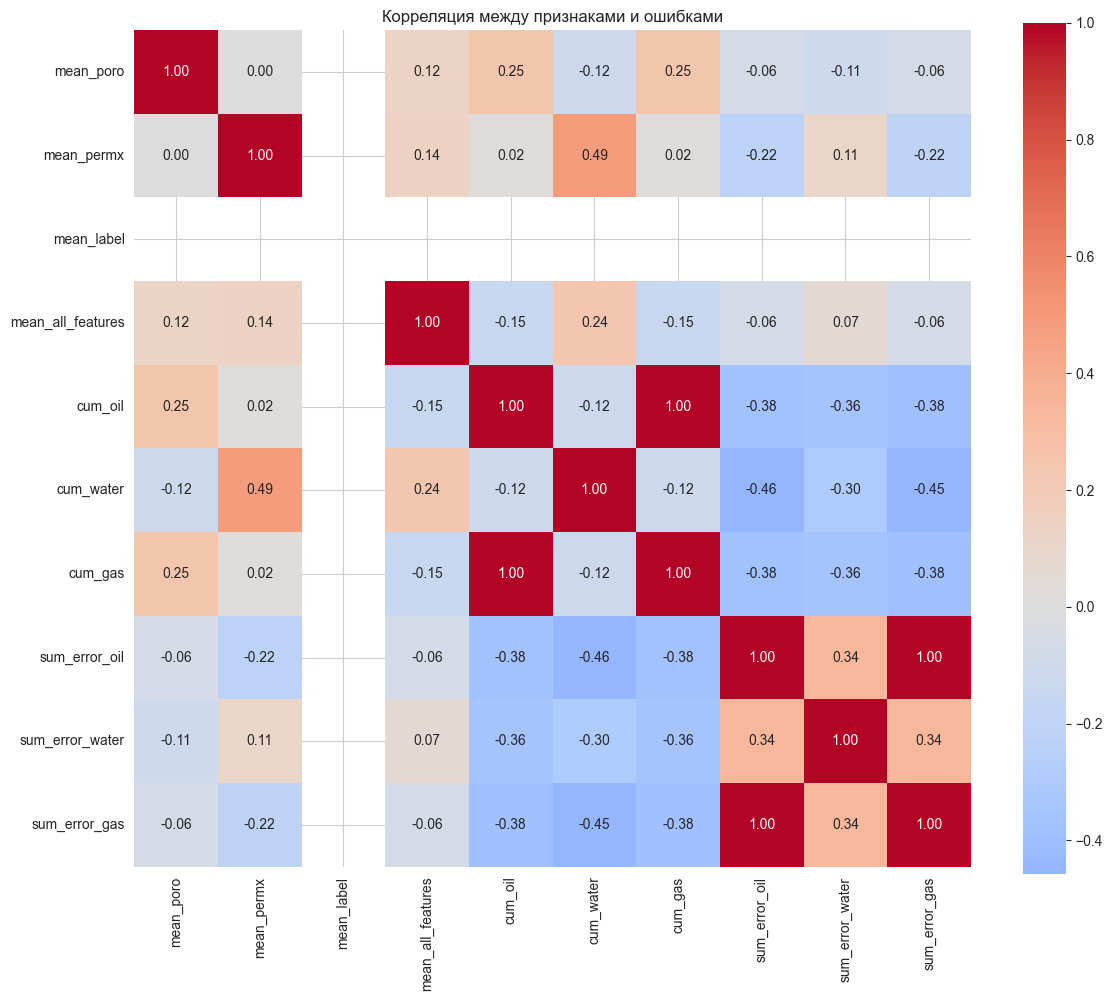

In [39]:
# ----------------------------------------------------------------------
# 4. Корреляционная матрица (только для числовых признаков)
# ----------------------------------------------------------------------
# Выбираем числовые колонки
numeric_cols = ['mean_poro', 'mean_permx', 'mean_label', 'mean_all_features',
                'cum_oil', 'cum_water', 'cum_gas',
                'sum_error_oil', 'sum_error_water', 'sum_error_gas']
corr_data = df_outliers_table[numeric_cols].dropna()
corr = corr_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Корреляция между признаками и ошибками')
plt.tight_layout()
plt.show()

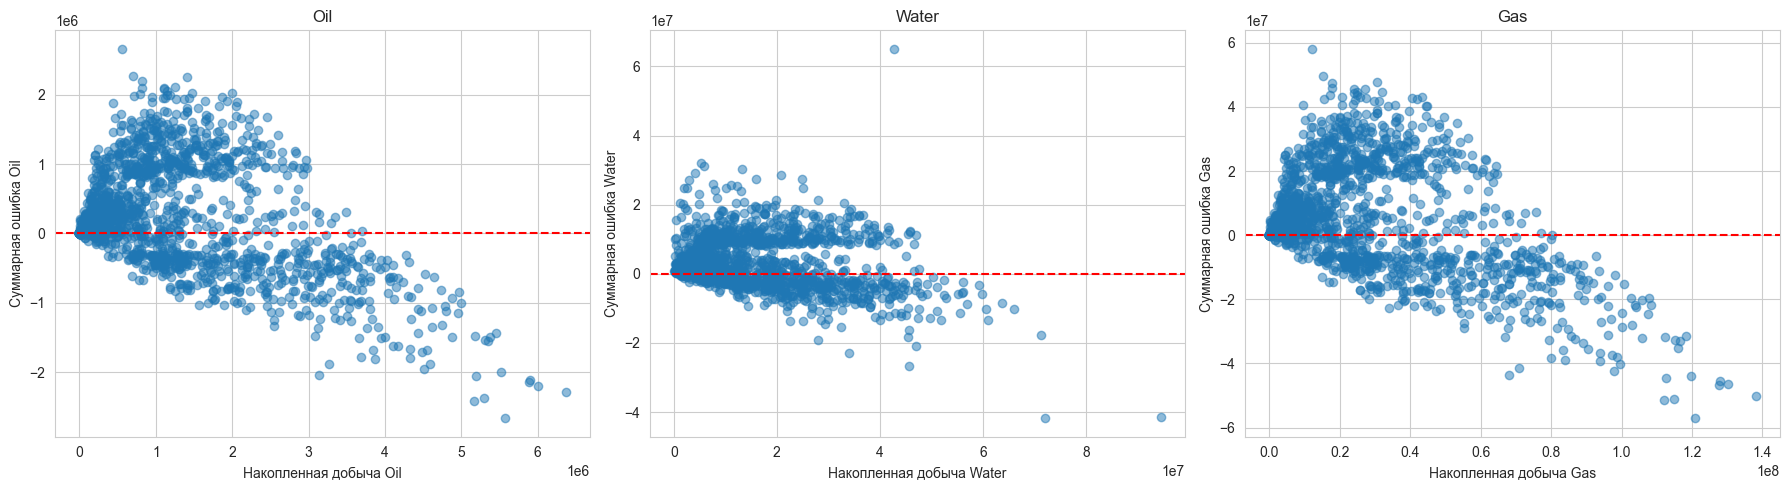

In [40]:
# ----------------------------------------------------------------------
# 5. Scatter ошибки от накопленной добычи
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, phase in enumerate(phases):
    ax = axes[i]
    ax.scatter(df_outliers_table[f'cum_{phase.lower()}'], df_outliers_table[error_cols[i]], alpha=0.5)
    ax.set_xlabel(f'Накопленная добыча {phase}')
    ax.set_ylabel(f'Суммарная ошибка {phase}')
    ax.set_title(phase)
    ax.axhline(0, color='red', linestyle='--')
    ax.grid(True)
plt.tight_layout()
plt.show()

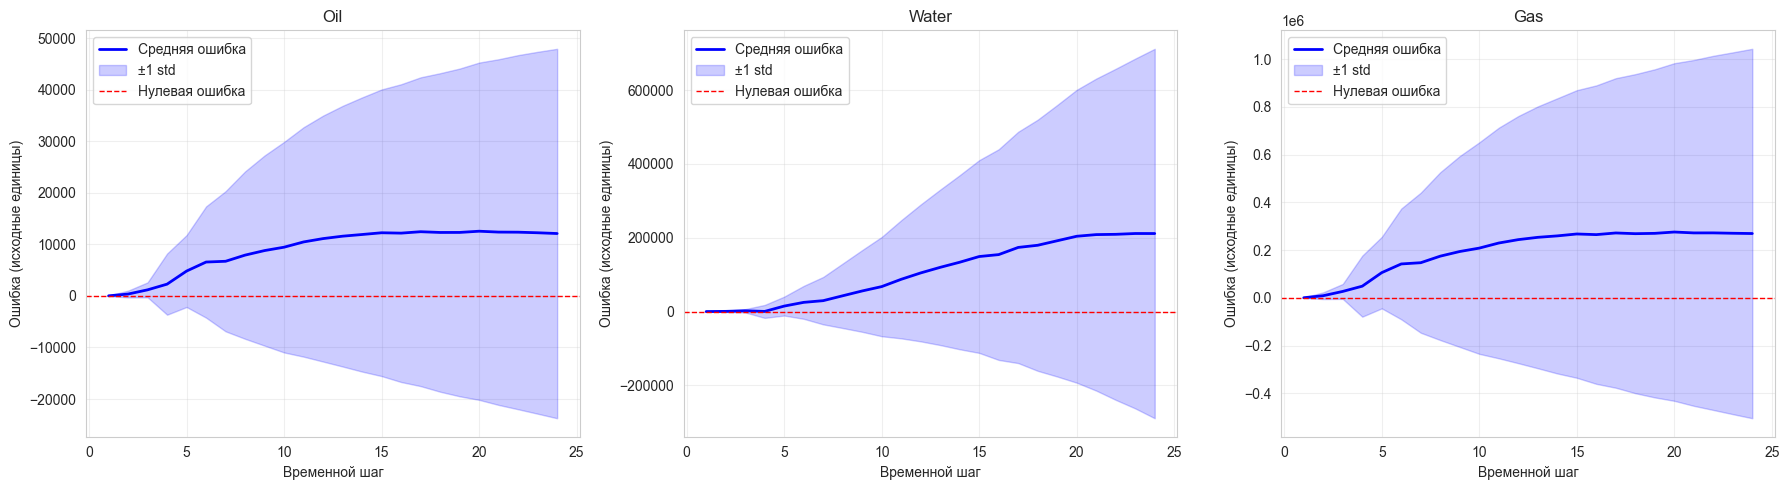

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагается, что preds_original и targets_original уже получены
# (см. раздел 4.1, обратное преобразование в исходные единицы)
# preds_original, targets_original: (total_wells, 3, 24)

phases = ['Oil', 'Water', 'Gas']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, phase in enumerate(phases):
    # Ошибка для фазы: (total_wells, 24)
    error = (preds_original[:, i, :] - targets_original[:, i, :]).numpy()
    
    # Средняя ошибка и стандартное отклонение по каждому шагу
    mean_error = error.mean(axis=0)
    std_error = error.std(axis=0)
    
    # Шаги времени (1..24)
    steps = np.arange(1, 25)
    
    ax = axes[i]
    ax.plot(steps, mean_error, 'b-', linewidth=2, label='Средняя ошибка')
    ax.fill_between(steps, mean_error - std_error, mean_error + std_error,
                    color='blue', alpha=0.2, label='±1 std')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Нулевая ошибка')
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Ошибка (исходные единицы)')
    ax.set_title(phase)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
import plotly.graph_objects as go
import pandas as pd
import json

# Предполагаем, что df_outliers_table уже определён и содержит нужные колонки:
# 'graph_name', 'well_index', 'cum_oil', 'cum_water', 'cum_gas',
# 'sum_error_oil', 'sum_error_water', 'sum_error_gas'

# Создаём уникальный идентификатор скважины
df_outliers_table['well_id'] = df_outliers_table['graph_name'] + '_' + df_outliers_table['well_index'].astype(str)
df_outliers_table = df_outliers_table.reset_index(drop=True)  # чтобы индексы были последовательными

# Находим индексы скважин, у которых суммарная ошибка по НЕФТИ < -500000
initial_highlight_indices = df_outliers_table.index[df_outliers_table['sum_error_oil'] > 900000].tolist()

# Список фаз и соответствующих колонок
phases = ['Oil', 'Water', 'Gas']
error_cols = ['sum_error_oil', 'sum_error_water', 'sum_error_gas']
cum_cols = ['cum_oil', 'cum_water', 'cum_gas']

# Подготовка данных для JavaScript
graphs_data = {}
for i, phase in enumerate(phases):
    df_sub = df_outliers_table[['well_id', cum_cols[i], error_cols[i]]]
    graphs_data[phase.lower()] = {
        'x': df_sub[cum_cols[i]].tolist(),
        'y': df_sub[error_cols[i]].tolist(),
        'customdata': df_sub['well_id'].tolist(),
        'phase': phase
    }

# Шаблон HTML с встроенным JavaScript
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>Синхронизированные графики выбросов</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .plot-container { display: flex; flex-wrap: wrap; justify-content: center; }
        .plot { width: 500px; height: 600px; margin: 10px; }
    </style>
</head>
<body>
    <div class="plot-container">
        <div id="graph-oil" class="plot"></div>
        <div id="graph-water" class="plot"></div>
        <div id="graph-gas" class="plot"></div>
    </div>
    <script>
        const graphsData = {graphs_data_json};
        const initialIndices = {initial_indices_json};

        // Функция создания графика
        function createGraph(phaseKey, divId) {
            const data = graphsData[phaseKey];
            
            // Основной слой со всеми точками (trace 0)
            const traceBase = {
                x: data.x,
                y: data.y,
                mode: 'markers',
                marker: { color: 'blue', size: 8, opacity: 0.6 }, // Полупрозрачные базовые точки
                customdata: data.customdata,
                hovertemplate: `<b>${data.phase}</b><br>Накопленная добыча: %{{x:.2f}}<br>Суммарная ошибка: %{{y:.2f}}<br>Скважина: %{{customdata}}<extra></extra>`,
                name: 'Все скважины',
                showlegend: false
            };

            // Формируем слой для выделения (trace 1)
            let h_x = [], h_y = [], h_customdata =[];
            
            // Теперь подсвечиваем проблемные скважины изначально НА ВСЕХ графиках
            // (Убрали условие if (phaseKey === 'water' || phaseKey === 'gas'))
            initialIndices.forEach(i => {
                h_x.push(data.x[i]);
                h_y.push(data.y[i]);
                h_customdata.push(data.customdata[i]);
            });

            const traceHighlight = {
                x: h_x,
                y: h_y,
                mode: 'markers',
                marker: { 
                    color: 'red', 
                    size: 11, // Подсвеченные точки крупнее
                    line: { color: 'black', width: 1.5 } // Обводка выделенных точек
                },
                customdata: h_customdata,
                hovertemplate: `<b>${data.phase} (Выделена)</b><br>Накопленная добыча: %{{x:.2f}}<br>Суммарная ошибка: %{{y:.2f}}<br>Скважина: %{{customdata}}<extra></extra>`,
                name: 'Выделенные скважины',
                showlegend: false
            };
            
            const layout = {
                title: data.phase,
                xaxis: { title: 'Накопленная добыча' },
                yaxis: { title: 'Суммарная ошибка' },
                hovermode: 'closest',
                width: 500,
                height: 600
            };
            
            // Строим график сразу с двумя слоями:
            // index 0: все скважины, index 1: выделенные (изначально проблемные)
            Plotly.newPlot(divId, [traceBase, traceHighlight], layout).then(() => {
                const plotDiv = document.getElementById(divId);
                plotDiv.on('plotly_click', function(eventData) {
                    if (eventData.points.length > 0) {
                        const clickedWellId = eventData.points[0].customdata;
                        const index = data.customdata.indexOf(clickedWellId);
                        
                        if (index !== -1) {
                            highlightPoint(index);
                        }
                    }
                });
            });
        }

        // Подсветка одной точки при клике: заменяет массив выделенных точек на одну выбранную
        function highlightPoint(index) {
            const phases =['oil', 'water', 'gas'];
            phases.forEach(phaseKey => {
                const divId = `graph-${phaseKey}`;
                const data = graphsData[phaseKey];
                
                // Данные выбранной при клике точки
                const h_x = [data.x[index]];
                const h_y = [data.y[index]];
                const h_customdata = [data.customdata[index]];

                // Обновляем слой выделения (trace 1) на всех графиках
                Plotly.restyle(divId, {
                    x: [h_x],
                    y:[h_y],
                    customdata: [h_customdata]
                }, 1); 
            });
        }

        // Создаём все три графика
        createGraph('oil', 'graph-oil');
        createGraph('water', 'graph-water');
        createGraph('gas', 'graph-gas');
    </script>
</body>
</html>
"""

# Конвертируем данные и индексы в JSON
graphs_data_json = json.dumps(graphs_data)
initial_indices_json = json.dumps(initial_highlight_indices)

# Вставляем данные в шаблон
html = html_template.replace('{graphs_data_json}', graphs_data_json)
html = html.replace('{initial_indices_json}', initial_indices_json)

# Сохраняем HTML-файл
with open('sync_plots_oil.html', 'w', encoding='utf-8') as f:
    f.write(html)
print("HTML-файл сохранён как sync_plots_oil.html")

HTML-файл сохранён как sync_plots_oil.html


In [35]:
import plotly.graph_objects as go
import pandas as pd
import json

# Предполагаем, что df_outliers_table уже определён и содержит нужные колонки:
# 'graph_name', 'well_index', 'cum_oil', 'cum_water', 'cum_gas',
# 'sum_error_oil', 'sum_error_water', 'sum_error_gas'

# Создаём уникальный идентификатор скважины
df_outliers_table['well_id'] = df_outliers_table['graph_name'] + '_' + df_outliers_table['well_index'].astype(str)
df_outliers_table = df_outliers_table.reset_index(drop=True)  # чтобы индексы были последовательными

# Находим индексы скважин, у которых суммарная ошибка по ВОДЕ больше 0.5
initial_highlight_indices = df_outliers_table.index[df_outliers_table['sum_error_water'] > 6000000].tolist()

# Список фаз и соответствующих колонок
phases =['Oil', 'Water', 'Gas']
error_cols =['sum_error_oil', 'sum_error_water', 'sum_error_gas']
cum_cols =['cum_oil', 'cum_water', 'cum_gas']

# Подготовка данных для JavaScript
graphs_data = {}
for i, phase in enumerate(phases):
    df_sub = df_outliers_table[['well_id', cum_cols[i], error_cols[i]]]
    graphs_data[phase.lower()] = {
        'x': df_sub[cum_cols[i]].tolist(),
        'y': df_sub[error_cols[i]].tolist(),
        'customdata': df_sub['well_id'].tolist(),
        'phase': phase
    }

# Шаблон HTML с встроенным JavaScript
html_template = """
<!DOCTYPE html>
<html>
<head>
    <title>Синхронизированные графики выбросов</title>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        .plot-container { display: flex; flex-wrap: wrap; justify-content: center; }
        .plot { width: 500px; height: 600px; margin: 10px; }
    </style>
</head>
<body>
    <div class="plot-container">
        <div id="graph-oil" class="plot"></div>
        <div id="graph-water" class="plot"></div>
        <div id="graph-gas" class="plot"></div>
    </div>
    <script>
        const graphsData = {graphs_data_json};
        const initialIndices = {initial_indices_json};

        // Функция создания графика
        function createGraph(phaseKey, divId) {
            const data = graphsData[phaseKey];
            
            // Основной слой со всеми точками (trace 0)
            const traceBase = {
                x: data.x,
                y: data.y,
                mode: 'markers',
                marker: { color: 'blue', size: 8, opacity: 0.6 }, // Полупрозрачные базовые точки
                customdata: data.customdata,
                hovertemplate: `<b>${data.phase}</b><br>Накопленная добыча: %{{x:.2f}}<br>Суммарная ошибка: %{{y:.2f}}<br>Скважина: %{{customdata}}<extra></extra>`,
                name: 'Все скважины',
                showlegend: false
            };

            // Формируем слой для выделения (trace 1)
            let h_x =[], h_y = [], h_customdata =[];
            
            // Изначально подсвечиваем проблемные по воде скважины на графиках с НЕФТЬЮ и ГАЗОМ
            initialIndices.forEach(i => {
                h_x.push(data.x[i]);
                h_y.push(data.y[i]);
                h_customdata.push(data.customdata[i]);
            });

            const traceHighlight = {
                x: h_x,
                y: h_y,
                mode: 'markers',
                marker: { 
                    color: 'red', 
                    size: 11, // Подсвеченные точки крупнее
                    line: { color: 'black', width: 1.5 } // Обводка выделенных точек
                },
                customdata: h_customdata,
                hovertemplate: `<b>${data.phase} (Выделена)</b><br>Накопленная добыча: %{{x:.2f}}<br>Суммарная ошибка: %{{y:.2f}}<br>Скважина: %{{customdata}}<extra></extra>`,
                name: 'Выделенные скважины',
                showlegend: false
            };
            
            const layout = {
                title: data.phase,
                xaxis: { title: 'Накопленная добыча' },
                yaxis: { title: 'Суммарная ошибка' },
                hovermode: 'closest',
                width: 500,
                height: 600
            };
            
            // Строим график сразу с двумя слоями
            Plotly.newPlot(divId, [traceBase, traceHighlight], layout).then(() => {
                const plotDiv = document.getElementById(divId);
                plotDiv.on('plotly_click', function(eventData) {
                    if (eventData.points.length > 0) {
                        const clickedWellId = eventData.points[0].customdata;
                        const index = data.customdata.indexOf(clickedWellId);
                        
                        if (index !== -1) {
                            highlightPoint(index);
                        }
                    }
                });
            });
        }

        // Подсветка одной точки при клике: заменяет массив выделенных точек на одну выбранную
        function highlightPoint(index) {
            const phases = ['oil', 'water', 'gas'];
            phases.forEach(phaseKey => {
                const divId = `graph-${phaseKey}`;
                const data = graphsData[phaseKey];
                
                // Данные выбранной при клике точки
                const h_x =[data.x[index]];
                const h_y = [data.y[index]];
                const h_customdata = [data.customdata[index]];

                // Обновляем слой выделения (trace 1) на всех графиках
                Plotly.restyle(divId, {
                    x:[h_x],
                    y: [h_y],
                    customdata: [h_customdata]
                }, 1); 
            });
        }

        // Создаём все три графика
        createGraph('oil', 'graph-oil');
        createGraph('water', 'graph-water');
        createGraph('gas', 'graph-gas');
    </script>
</body>
</html>
"""

# Конвертируем данные и индексы в JSON
graphs_data_json = json.dumps(graphs_data)
initial_indices_json = json.dumps(initial_highlight_indices)

# Вставляем данные в шаблон
html = html_template.replace('{graphs_data_json}', graphs_data_json)
html = html.replace('{initial_indices_json}', initial_indices_json)

# Сохраняем HTML-файл
with open('sync_plots_water_2.html', 'w', encoding='utf-8') as f:
    f.write(html)
print("HTML-файл сохранён как sync_plots_water_2.html")

HTML-файл сохранён как sync_plots_water_2.html


In [36]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Предположим, у вас есть DataFrame df_outliers_table, содержащий:
#   'graph_name', 'well_index', 'cum_oil', 'cum_water', 'cum_gas',
#   'sum_error_oil', 'sum_error_water', 'sum_error_gas'
# Создадим уникальный ID
df_outliers_table['well_id'] = df_outliers_table['graph_name'] + '_' + df_outliers_table['well_index'].astype(str)

# Определим фазы
phases = ['Oil', 'Water', 'Gas']
error_cols = ['sum_error_oil', 'sum_error_water', 'sum_error_gas']
cum_cols = ['cum_oil', 'cum_water', 'cum_gas']

# Создаём фигуру с тремя субплотами в один ряд
fig = make_subplots(rows=1, cols=3, 
                    subplot_titles=[f'Ошибка vs Накопленная добыча ({p})' for p in phases],
                    shared_yaxes=False)

# Для каждого графика добавляем точки
for i, phase in enumerate(phases):
    fig.add_trace(
        go.Scatter(
            x=df_outliers_table[cum_cols[i]],
            y=df_outliers_table[error_cols[i]],
            mode='markers',
            marker=dict(color='blue', size=6, opacity=0.6),
            name=phase,
            customdata=df_outliers_table[['well_id', 'graph_name', 'well_index']],  # храним доп. данные
            hovertemplate=(
                f'<b>{phase}</b><br>' +
                'Накопленная добыча: %{x:.2f}<br>' +
                'Суммарная ошибка: %{y:.2f}<br>' +
                'Скважина: %{customdata[1]}<br>' +
                'Индекс: %{customdata[2]}<extra></extra>'
            )
        ),
        row=1, col=i+1
    )

# Настройки осей и внешнего вида
fig.update_xaxes(title_text='Накопленная добыча', row=1, col=1)
fig.update_yaxes(title_text='Суммарная ошибка', row=1, col=1)
fig.update_xaxes(title_text='Накопленная добыча', row=1, col=2)
fig.update_yaxes(title_text='Суммарная ошибка', row=1, col=2)
fig.update_xaxes(title_text='Накопленная добыча', row=1, col=3)
fig.update_yaxes(title_text='Суммарная ошибка', row=1, col=3)

fig.update_layout(
    title='Анализ выбросов: ошибка vs накопленная добыча',
    showlegend=False,
    hovermode='closest',
    width=1200, height=500
)

fig.write_html('sync_plot.html')